## Spike2 to NWB data Conversion

This notebook converts the spike2 datasets to the NWB format. Without the spike2 data this cannot be run, but included in the repository for completeness.

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import pynwb
print(pynwb.__version__)
import json
import neo
import numpy as np
import pandas as pd
import quantities as pq
from quantities import s
from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo
import matplotlib.pyplot as plt
from excel_validator import validate_excel

from rvm_analysis.utils import import_neutral_cells,import_extra_cells,import_spontaneous_cells,import_on_off_trials,import_neutral_cells_extra
from pynwb.file import Subject
from pynwb import NWBFile, NWBHDF5IO
from pynwb.misc import AnnotationSeries
from pynwb.ecephys import SpikeEventSeries
from pynwb.behavior import BehavioralEvents

%matplotlib inline

3.1.3


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

In [3]:
dm_on_off_trials = import_on_off_trials()
dm_neutral = import_neutral_cells()
dm_spontaneous = import_spontaneous_cells()
dm_neutral_extra = import_neutral_cells_extra()
dm_on_off_extra = import_extra_cells()

dms = [dm_on_off_trials,
dm_neutral,
dm_spontaneous,
dm_neutral_extra,
dm_on_off_extra]

for dm in dms:
    for block in dm.blocks:
        for event in block.segments[0].events:
            if event.name in ["Keyboard","keyboard"]:
                event.name = "pinch"

<sonpy.SonFile> object owning file ..\..\data\Tail_Flick_Recordings_De_Preter\Spike_Files\DMHLido20_BL_cut.smrx
time values [17, 28, 46, 10, 18, 7, 2014]
The start of sampling was:  2014-07-18 10:46:28
time values [17, 28, 46, 10, 18, 7, 2014]
    DataType.AdcMark: 1, Spikes
Saving the unit with id 1, channel ind1
Saving the unit with id 2, channel ind1
    DataType.EventRise: 6, heat
    DataType.EventRise: 7, flick
signal_channels []
<sonpy.SonFile> object owning file ..\..\data\Tail_Flick_Recordings_De_Preter\Spike_Files\DP_DTT_Bic02_BL_cut.smrx
time values [16, 35, 57, 12, 6, 5, 2022]
The start of sampling was:  2022-05-06 12:57:35
time values [16, 35, 57, 12, 6, 5, 2022]
    DataType.AdcMark: 1, Spikes
Saving the unit with id 1, channel ind1
Saving the unit with id 2, channel ind1
    DataType.EventRise: 6, heat
    DataType.EventRise: 7, flick
signal_channels []
<sonpy.SonFile> object owning file ..\..\data\Tail_Flick_Recordings_De_Preter\Spike_Files\HDB_Bic06_BL_cut.smrx
time va

In [4]:
for dm in dms:
    for block in dm.blocks:
        print(block.segments[0].t_start,block.segments[0].spiketrains[0].t_stop)

0.0 s 1080.0 s
0.0 s 1080.0 s
0.0 s 1080.0 s
0.0 s 1074.0 s
0.0 s 1080.0 s
0.0 s 1080.0 s
0.0 s 1080.0 s
0.0 s 1080.0 s
0.0 s 1080.0 s
0.0 s 1080.0 s
0.0 s 1080.0 s
0.0 s 960.0 s
0.0 s 960.0 s
0.0 s 960.0 s
0.0 s 960.0 s
0.0 s 960.0 s
0.0 s 960.0 s
0.0 s 960.0 s
0.0 s 960.0 s
0.0 s 960.0 s
0.0 s 960.0 s
0.0 s 960.0 s
0.0 s 960.0 s
0.0 s 960.0 s
0.0 s 960.0 s
0.0 s 960.0 s
0.0 s 960.0 s
0.0 s 960.0 s
0.0 s 960.0 s
0.0 s 2557.0 s
0.0 s 2123.0 s
0.0 s 1800.0 s
0.0 s 2115.0 s
0.0 s 2098.0 s
0.0 s 2382.0 s
0.0 s 2084.0 s
0.0 s 2052.0 s
0.0 s 2259.0 s
0.0 s 2124.0 s
0.0 s 2055.0 s
0.0 s 2196.0 s
0.0 s 2022.0 s
0.0 s 1995.0 s
0.0 s 2355.0 s
0.0 s 2392.0 s
0.0 s 3178.0 s
0.0 s 2742.0 s
0.0 s 2952.0 s
0.0 s 3205.0 s
0.0 s 3368.0 s
0.0 s 2679.0 s
0.0 s 2636.0 s
0.0 s 2890.0 s
0.0 s 2824.0 s
0.0 s 3139.0 s
0.0 s 2588.0 s
0.0 s 2881.0 s
0.0 s 2920.0 s
0.0 s 3198.0 s
0.0 s 2470.0 s
0.0 s 2722.0 s
0.0 s 2923.0 s
0.0 s 2758.0 s
0.0 s 2661.0 s
0.0 s 2746.0 s
0.0 s 2969.0 s
0.0 s 3090.0 s
0.0 s 2760.0 

In [ ]:
for dm in dms:
    for i, block in enumerate(dm.blocks):
        print([event.name for event in block.segments[0].events])
        pinches = block.filter(name="pinch")
        if len(pinches) !=0:
            if len(pinches[0]) !=0:
                events: neo.Event = pinches[0]
                print(np.round(np.diff(events,prepend=0),3))
                print(events.labels)

['heat', 'flick']
['heat', 'flick']
['heat', 'flick']
['heat', 'flick']
['heat', 'flick']
['heat', 'flick']
['heat', 'flick']
['heat', 'flick']
['heat', 'flick']
['heat', 'flick']
['heat', 'flick']
['EKG', 'heat', 'flick', 'pinch']
['EKG', 'heat', 'flick', 'pinch']
['EKG', 'heat', 'flick', 'pinch']
['EKG', 'heat', 'flick', 'pinch']
['EKG', 'heat', 'flick', 'pinch']
['EKG', 'heat', 'flick', 'pinch']
['EKG', 'heat', 'flick', 'pinch']
['EKG', 'heat', 'flick', 'pinch']
['EKG', 'heat', 'flick', 'pinch']
['EKG', 'heat', 'flick', 'pinch']
['EKG', 'heat', 'flick', 'pinch']
['EKG', 'heat', 'flick', 'pinch']
['EKG', 'heat', 'flick', 'pinch']
['EKG', 'heat', 'flick', 'pinch']
['EKG', 'heat', 'flick', 'pinch']
['EKG', 'heat', 'flick', 'pinch']
['EKG', 'heat', 'flick', 'pinch']
['EKG', 'heat', 'flick', 'pinch']
['EKG', 'heat', 'flick', 'pinch']
['EKG', 'heat', 'flick', 'pinch']
[  19.003   10.371 1919.496    9.585   92.092   10.107   24.705   11.514] dimensionless
['l_hpaw_onset' 'l_hpaw_release' '

In [ ]:


def plot_segment(segment, normalize_analog=False, separate_analog_axes=False,figsize=(25,5)):
    """
    Plot a neo.Segment with:
      - One raster axis for all SpikeTrains and Events
      - AnalogSignals either on one shared axis or on separate axes
    """

    spiketrains = list(segment.spiketrains)
    events = list(segment.events)
    analogsignals = list(segment.analogsignals)

    n_analog_axes = len(analogsignals) if separate_analog_axes else (1 if analogsignals else 0)
    n_raster_axes = 1 if (len(spiketrains) + len(events) > 0) else 0
    n_axes = n_raster_axes + n_analog_axes

    fig, axes = plt.subplots(
        n_axes,
        1,
        figsize=(figsize[0], figsize[1] * n_axes),
        sharex=True,
        constrained_layout=True
    )

    if n_axes == 1:
        axes = [axes]

    # Raster plot
    if n_raster_axes:
        raster_ax = axes[0]

        y_positions = []
        y_labels = []
        y = 0

        # SpikeTrains
        for i, st in enumerate(spiketrains):
            times = st.rescale(pq.s).magnitude
            raster_ax.vlines(times, y - 0.4, y + 0.4)
            y_positions.append(y)
            y_labels.append(st.name or f"SpikeTrain {i}")
            y += 1

        # Events
        for i, ev in enumerate(events):
            times = ev.times.rescale(pq.s).magnitude
            raster_ax.vlines(times, y - 0.4, y + 0.4, color="tab:red")
            y_positions.append(y)
            y_labels.append(ev.name or f"Event {i}")
            y += 1

        raster_ax.set_yticks(y_positions)
        raster_ax.set_yticklabels(y_labels)
        raster_ax.set_ylabel("Spike trains / Events")
        raster_ax.set_title("Raster plot")
        raster_ax.grid(True, axis="x", alpha=0.3)

    # Analog signals
    for i, sig in enumerate(analogsignals):
        ax = axes[n_raster_axes + i] if separate_analog_axes else axes[n_raster_axes]
        t = sig.times.rescale(pq.s).magnitude
        data = sig.magnitude.squeeze()

        if normalize_analog:
            data = (data - np.mean(data)) / (np.max(np.abs(data)) + 1e-12)

        label = sig.name or f"AnalogSignal {i}"
        ax.plot(t, data, label=label)
        ax.set_ylabel(label if separate_analog_axes else "Analog signals")
        ax.grid(True, alpha=0.3)

    if analogsignals and not separate_analog_axes:
        axes[n_raster_axes].legend(loc="upper right")

    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(segment.name or "Neo Segment")

    plt.show()

..\..\data\Further_ON_OFF_Pairs_Mary\spike_files\LHb_Bic04_CA3.smrx


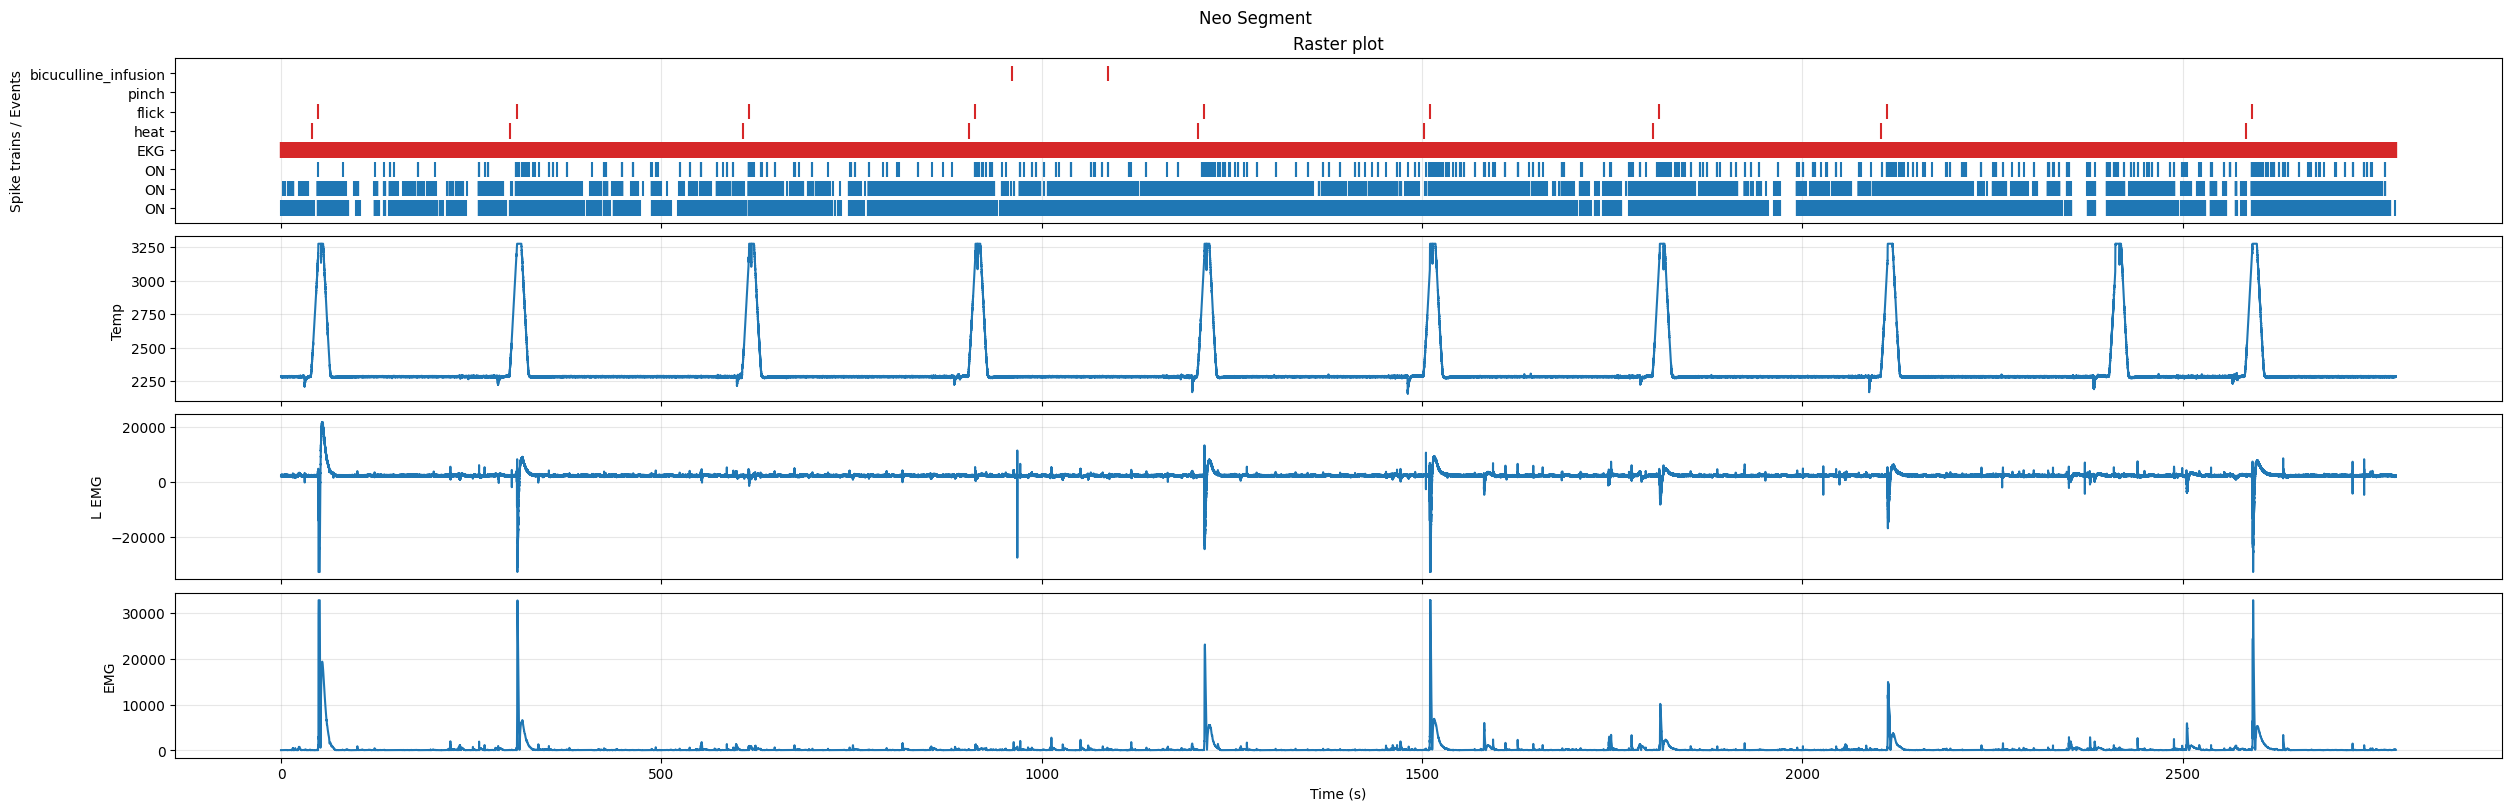

In [7]:
for block in dm_on_off_extra.blocks:
    print(block.file_origin)
    plot_segment(block.segments[0],normalize_analog=False,figsize=(25,2),separate_analog_axes=True)
    break

In [8]:
print(dm_on_off_extra.blocks[0].rec_datetime)

2022-07-22 10:09:36


In [ ]:
for dm in dms:
    for block in dm.blocks:
        segment: neo.Segment = block.segments[0]
        print([event.name for event in segment.analogsignals])

[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
['Temp ', 'L EMG']
['Temp ', 'L EMG']
['Temp ', 'L EMG']
['Temp ', 'L EMG']
['Temp ', 'L EMG']
['Temp ', 'L EMG']
['Temp ', 'L EMG']
['Temp ', 'L EMG']
['Temp ', 'L EMG']
['Temp ', 'L EMG']
['Temp ', 'L EMG']
['Temp ', 'L EMG']
['Temp ', 'L EMG']
['Temp ', 'L EMG']
['Temp ', 'L EMG']
['Temp ', 'L EMG']
['Temp ', 'L EMG']
['Temp ', 'L EMG']
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
['Temp ', 'L EMG', 'EMG']
['Temp ', 'L EMG', 'EMG']
['Temp ', 'L EMG', 'EMG']
['Temp ', 'L EMG', 'EMG']
['Temp ', 'L EMG', 'EMG']
['Temp ', 'L EMG', 'EMG']
['Temp ', 'L EMG', 'EMG']
['Temp ', 'L EMG', 'EMG']
['Temp ', 'L EMG', 'EMG']
['Temp ', 'L EMG', 'EMG']
['Temp ', 'L EMG', 'EMG']
['Temp ', 'L EMG', 'EMG']
['Temp ', 'L EMG', 'EMG']
['Temp ', 'L EMG', 'EMG']
['Temp ', 'L EMG', 'EMG']
['Temp ', 'L EMG', 'EMG']
['Temp ', 'L EMG', 'EMG']
['Temp ', 'L EMG', 'EMG']
['Temp ', 'L 

In [10]:
block: neo.Block = dms[0].blocks[0]
print(block._all_attrs)
print(block.rec_datetime)

(('file_datetime', <class 'datetime.datetime'>), ('rec_datetime', <class 'datetime.datetime'>), ('index', <class 'int'>), ('name', <class 'str'>), ('description', <class 'str'>), ('file_origin', <class 'str'>))
2014-07-18 10:46:28


..\..\data\Further_ON_OFF_Pairs_Mary\spike_files\LHb_Bic04_CA3.smrx


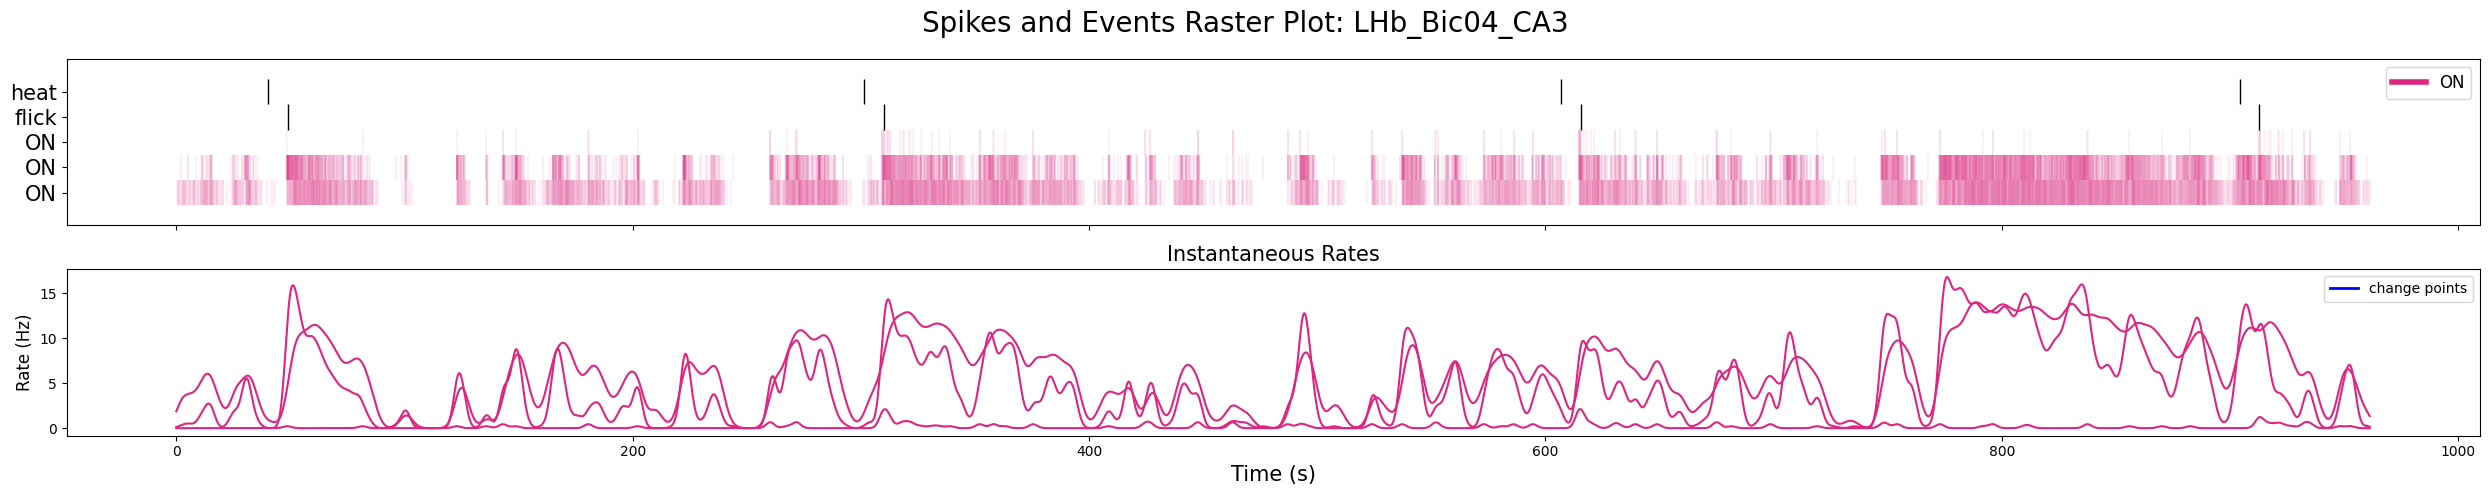

..\..\data\Further_ON_OFF_Pairs_Mary\spike_files\LHb_Bic05_CA3.smrx


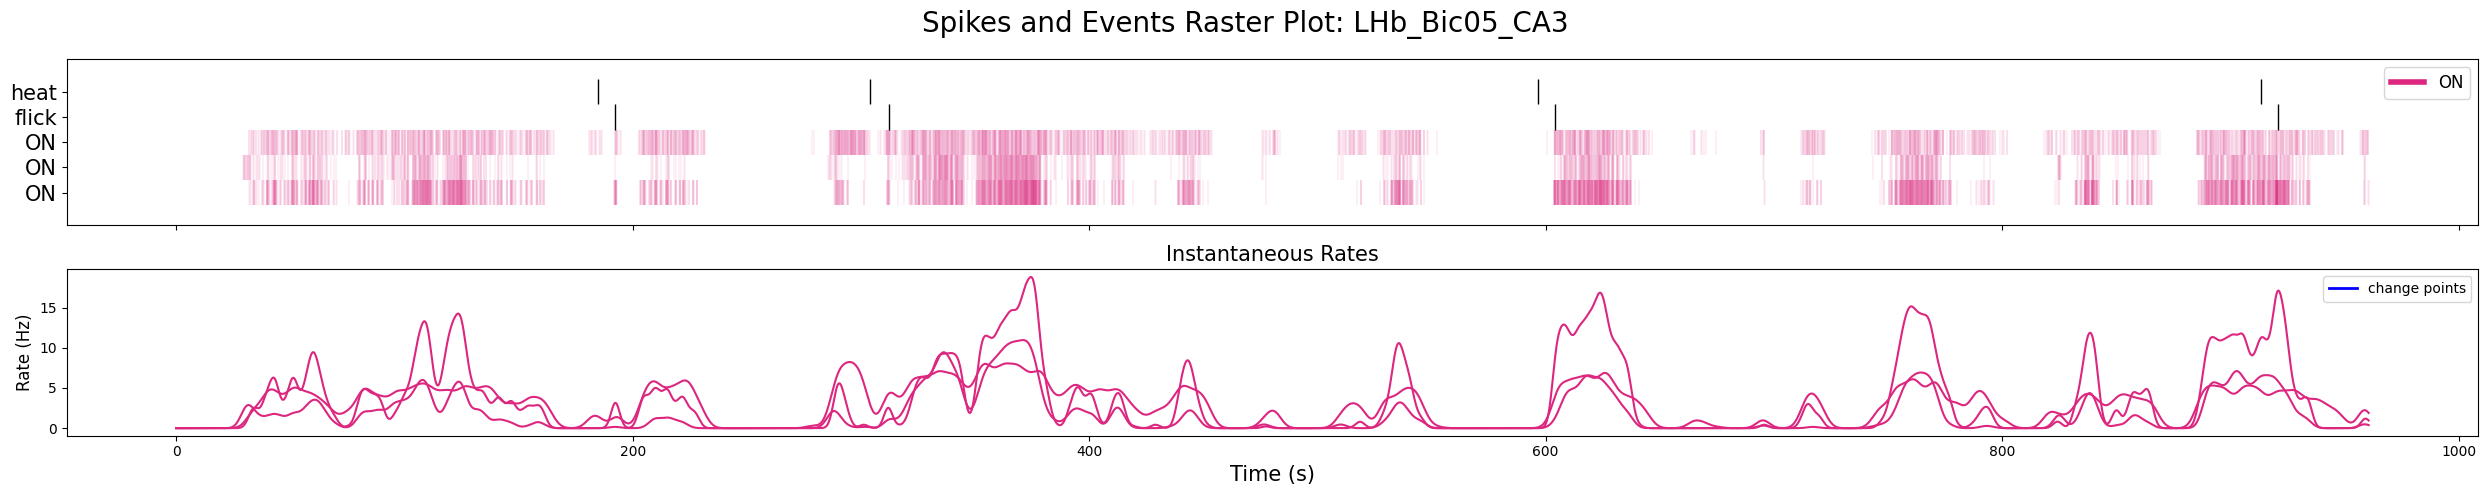

..\..\data\Further_ON_OFF_Pairs_Mary\spike_files\LHb_Bic07_CA3.smrx


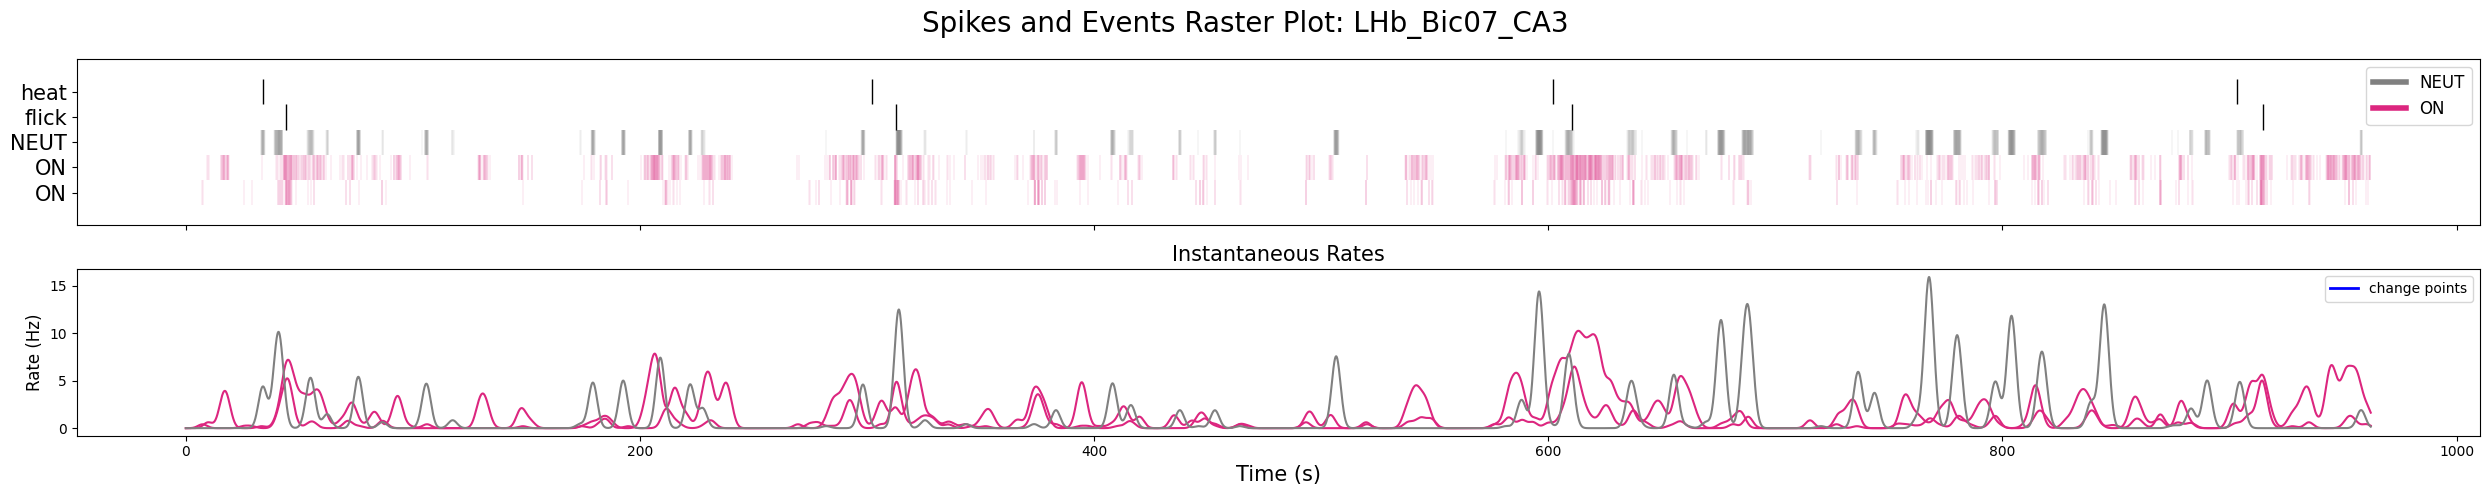

..\..\data\Further_ON_OFF_Pairs_Mary\spike_files\LHb_Bic16_CA2.smrx


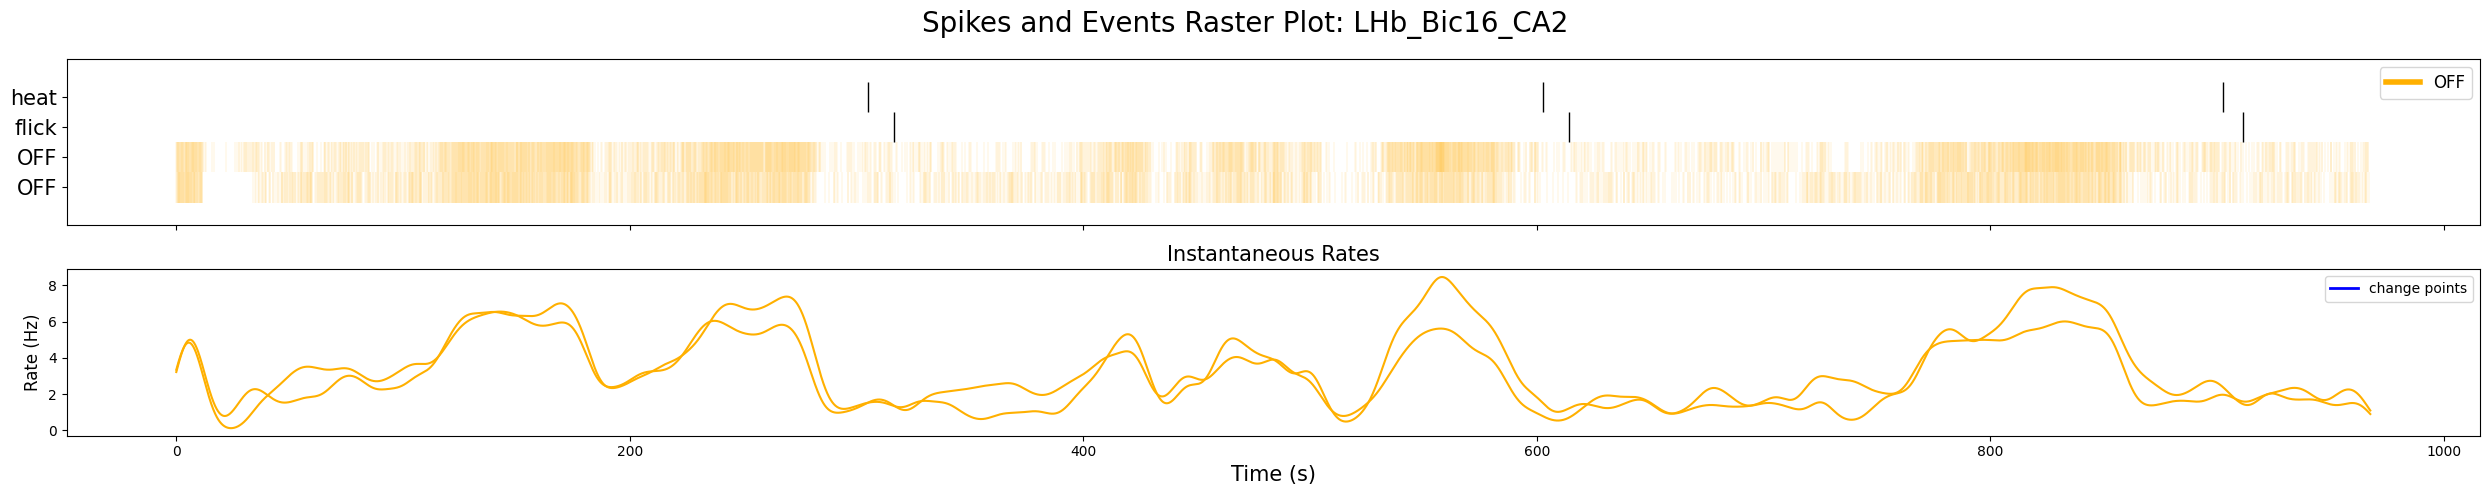

..\..\data\Further_ON_OFF_Pairs_Mary\spike_files\LHb_Bic20_CA3.smrx


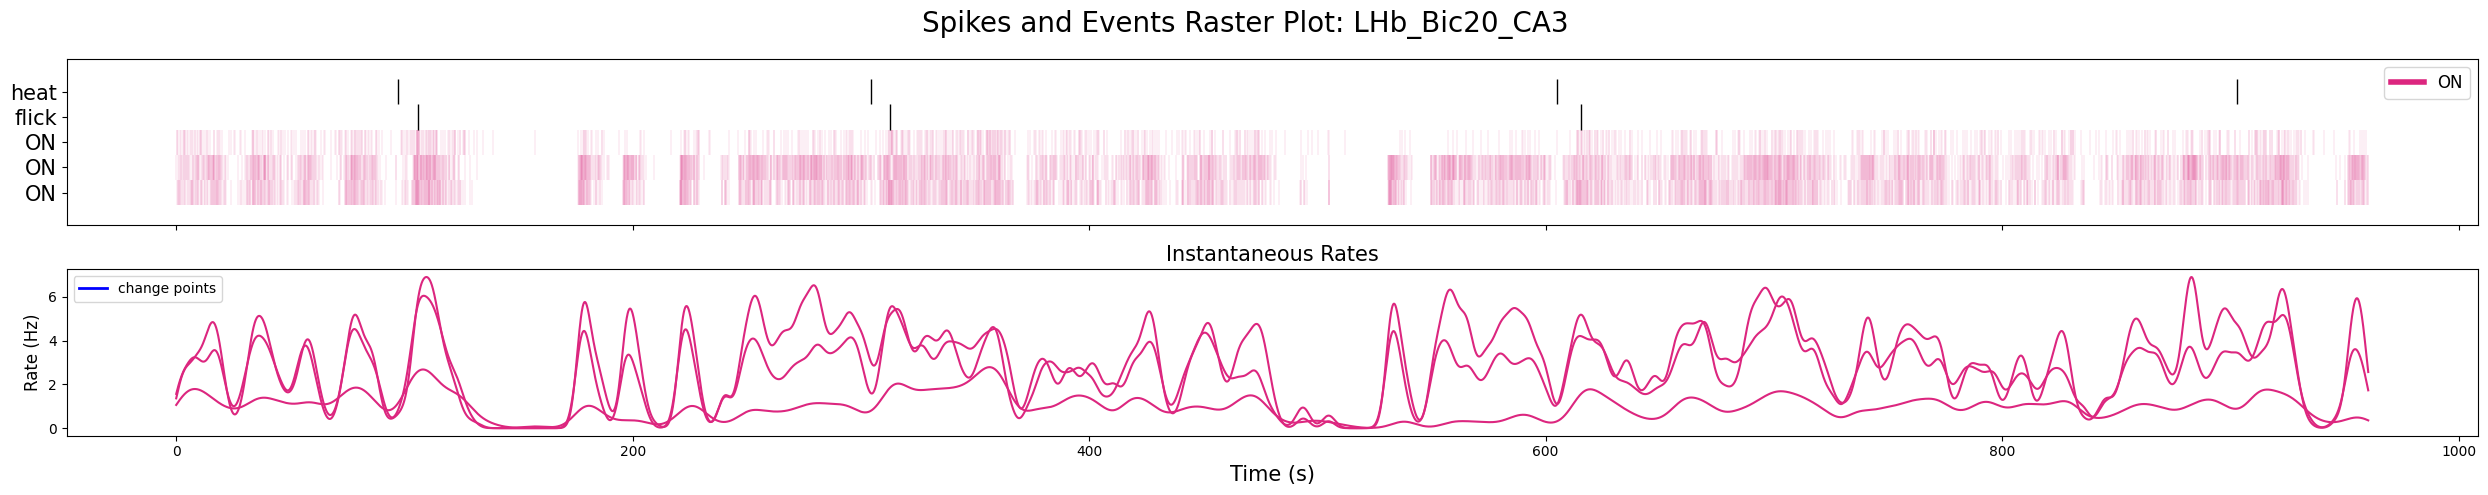

..\..\data\Further_ON_OFF_Pairs_Mary\spike_files\LHb_Bic27_CA2.smrx


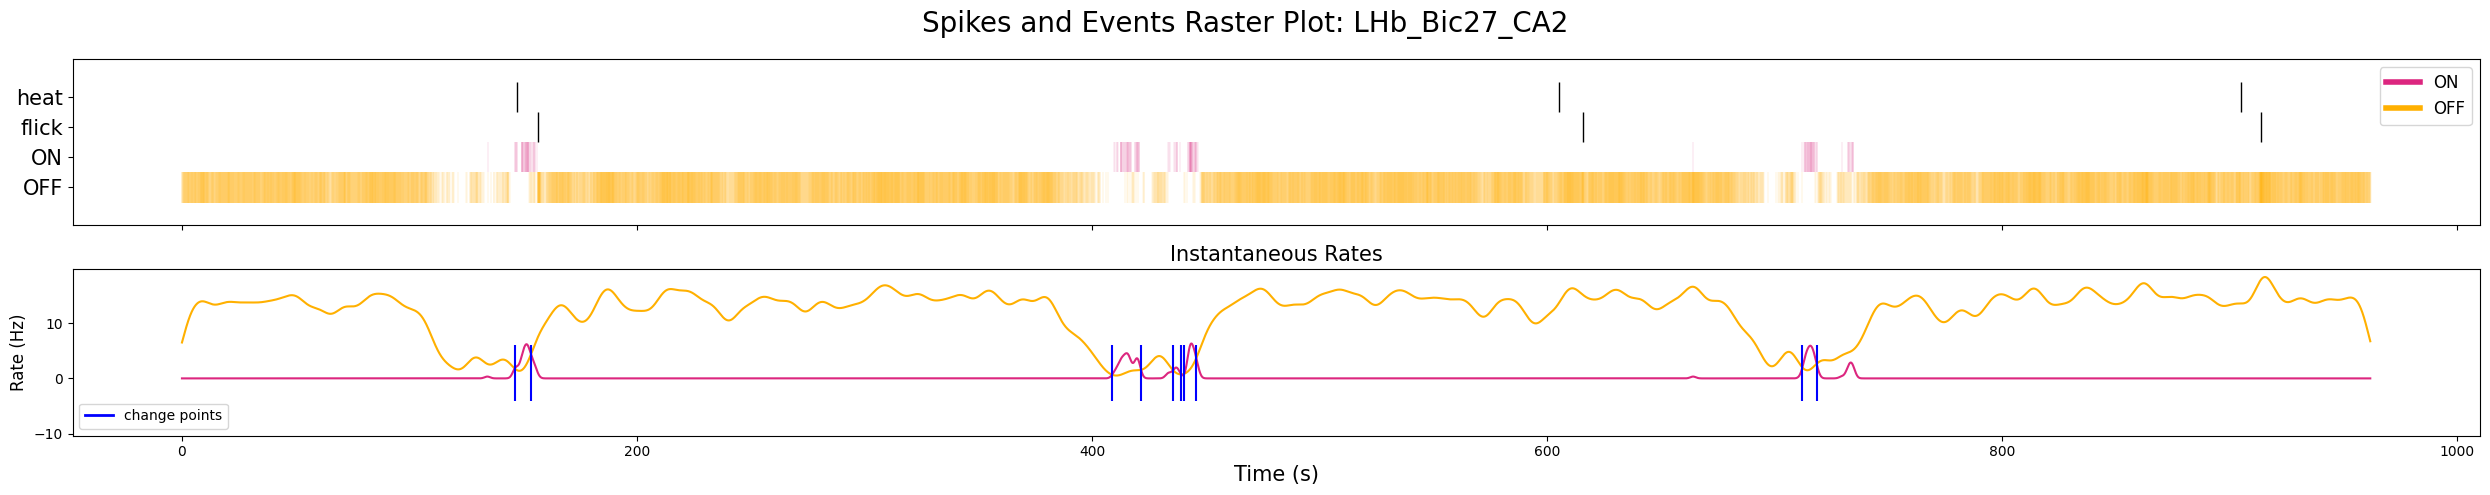

..\..\data\Further_ON_OFF_Pairs_Mary\spike_files\LHb_Bic36_CA2.smrx


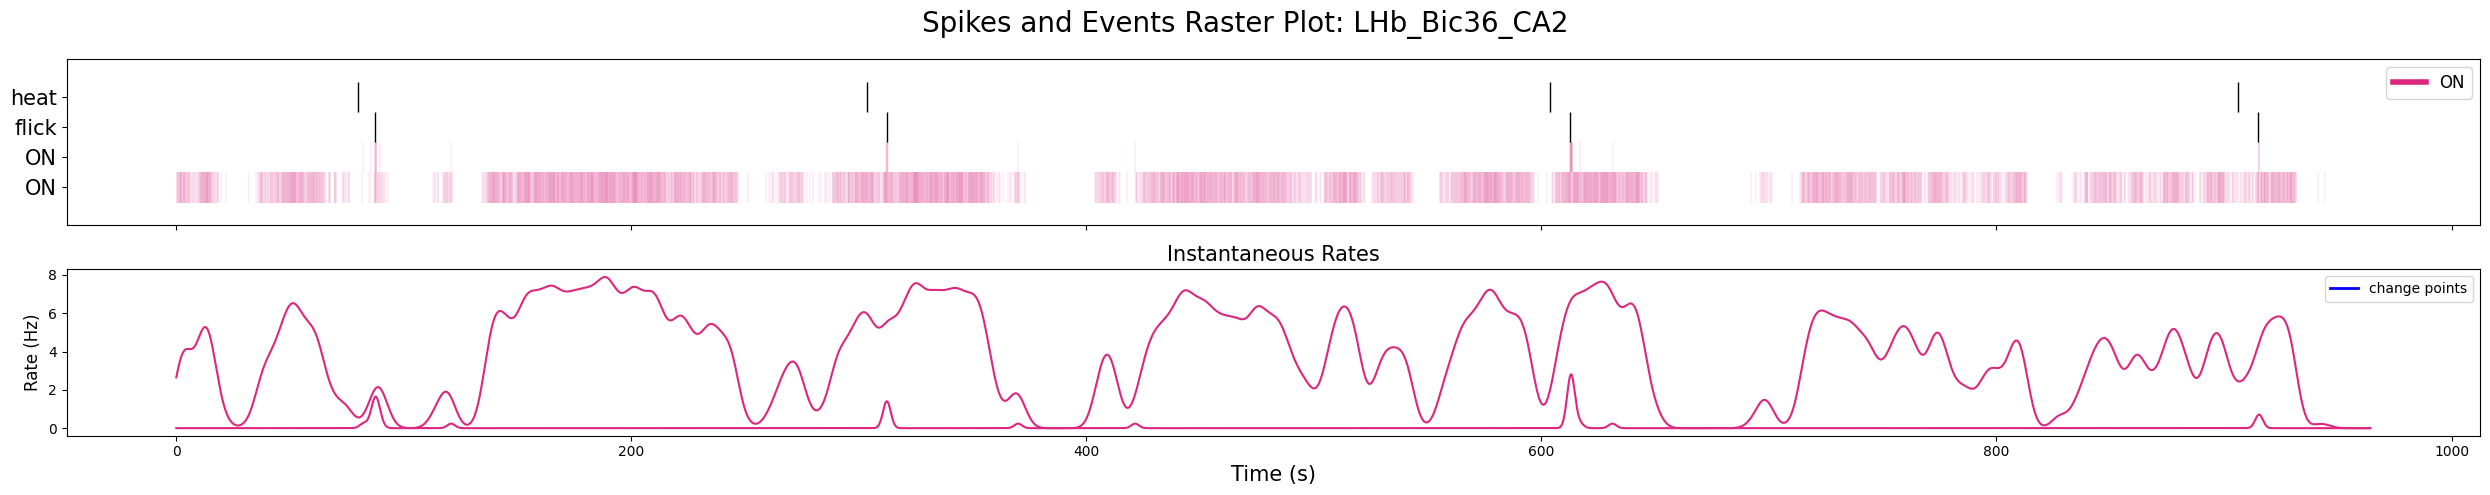

..\..\data\Further_ON_OFF_Pairs_Mary\spike_files\LHb_Bic38_CA2.smrx


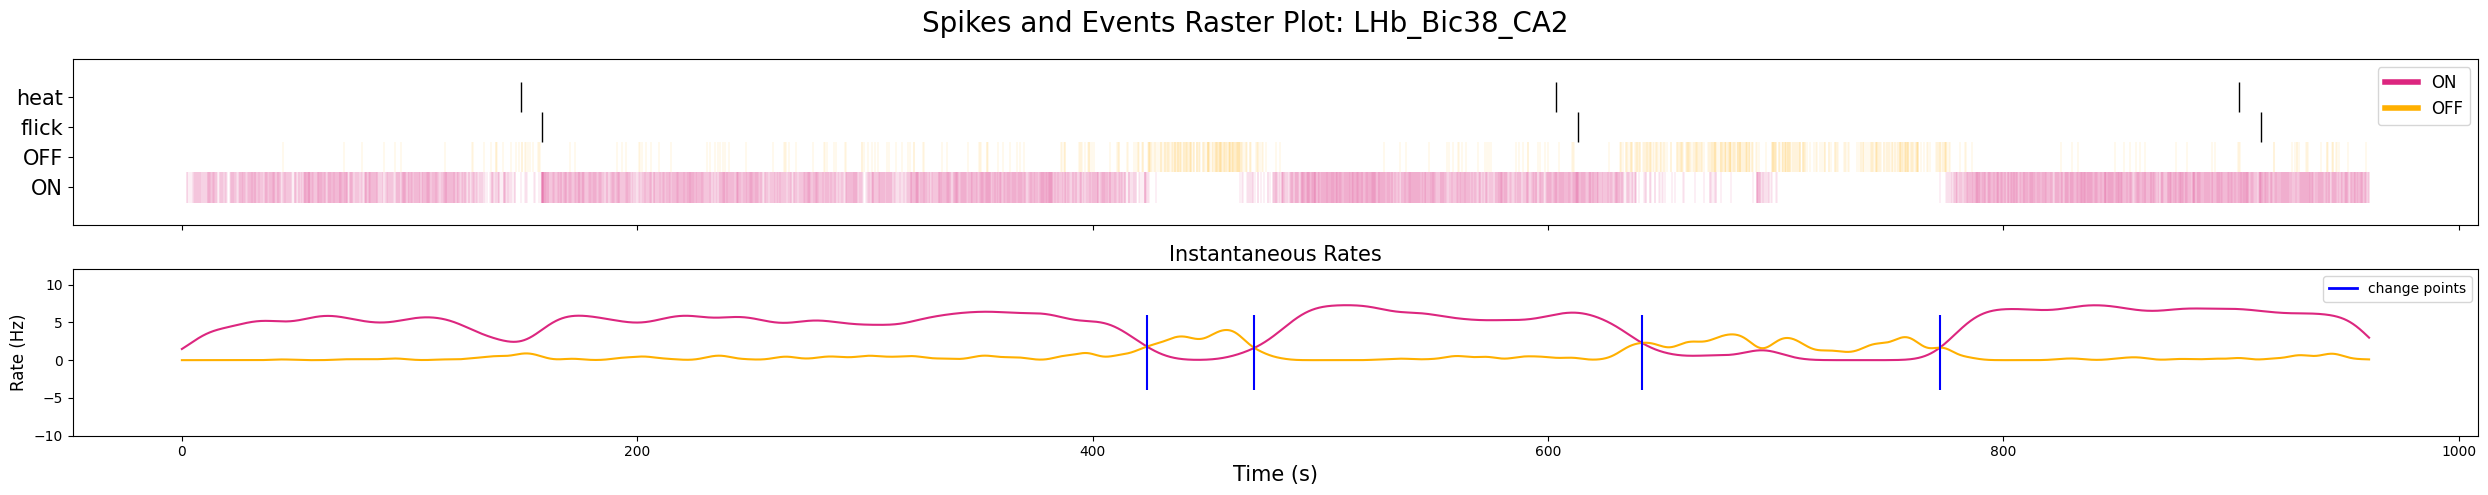

..\..\data\Further_ON_OFF_Pairs_Mary\spike_files\LHb_Bic42_CA3.smrx


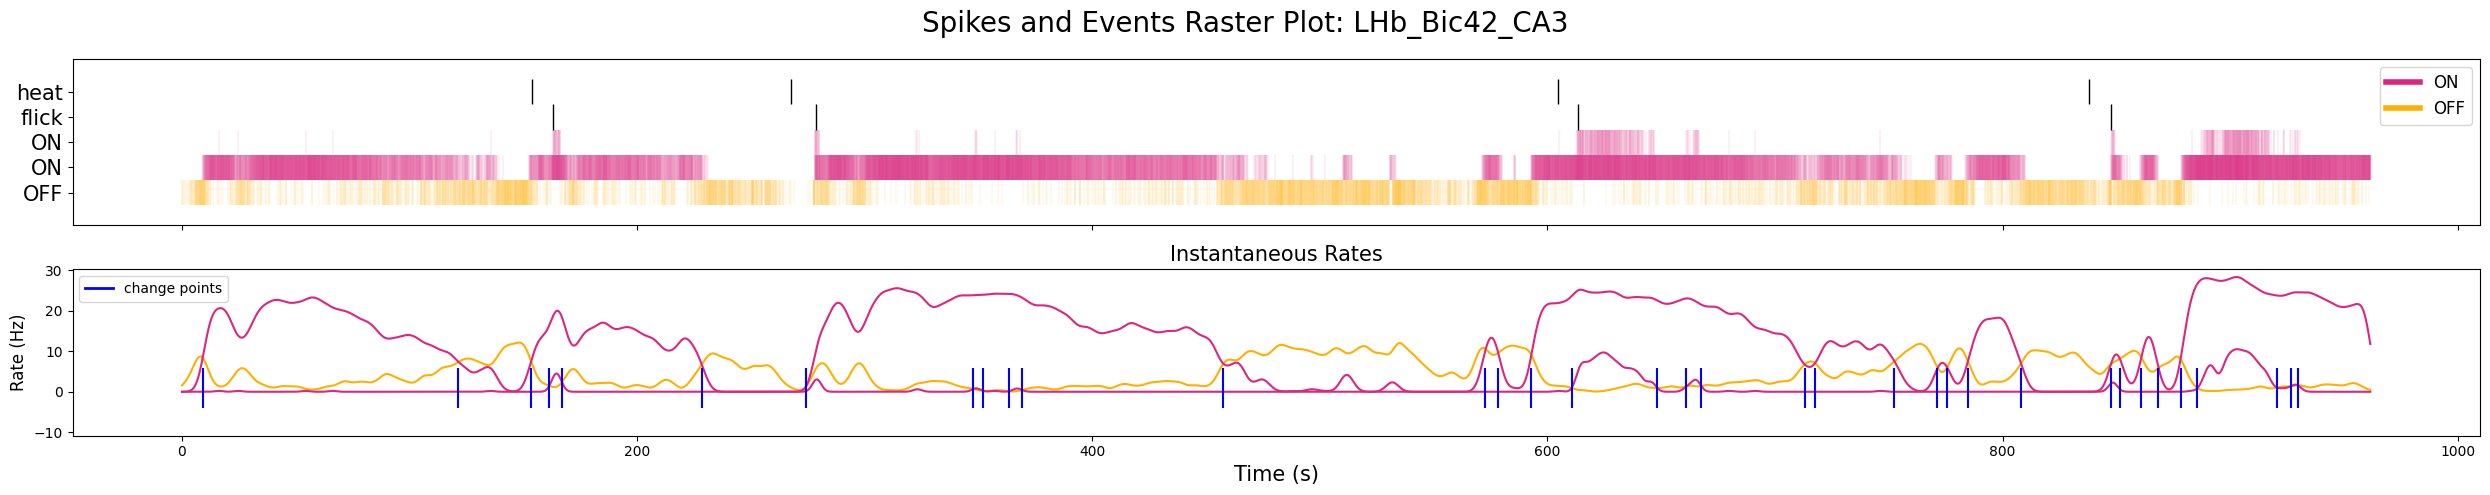

..\..\data\Further_ON_OFF_Pairs_Mary\spike_files\LHb_Bic49_CA3.smrx


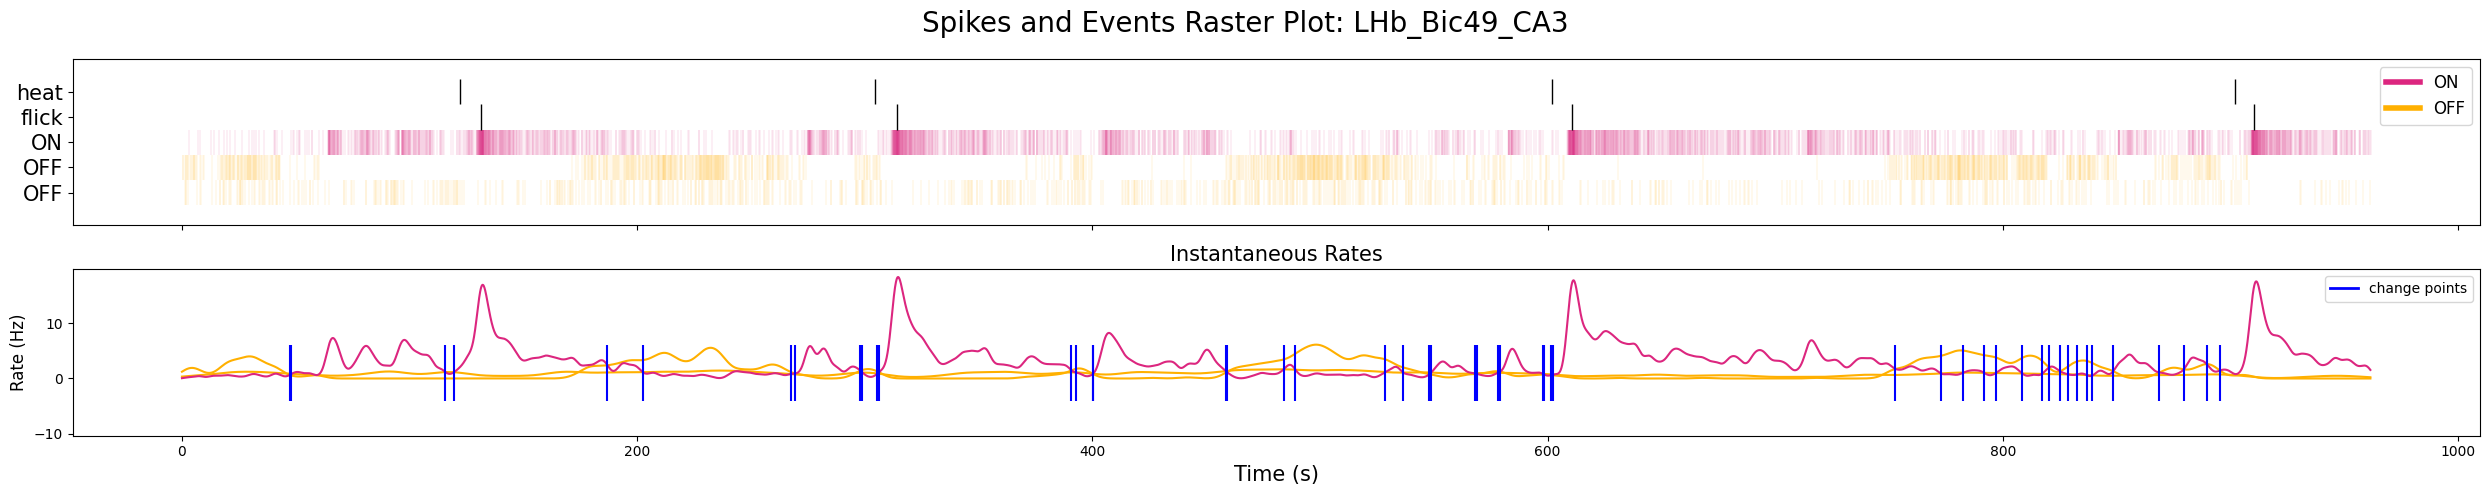

..\..\data\Further_ON_OFF_Pairs_Mary\spike_files\LHb_Bic51_CA4.smrx


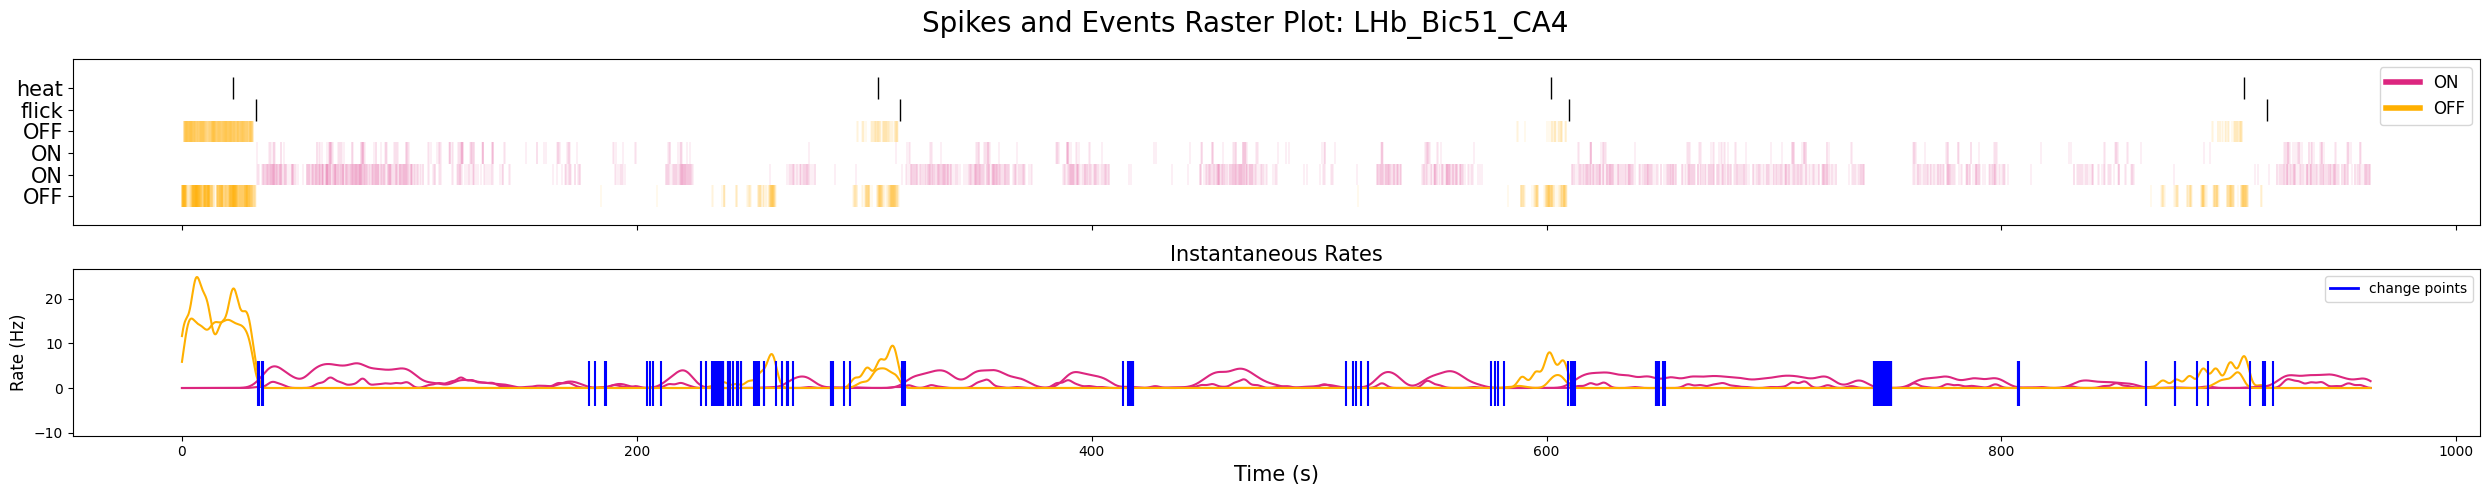

..\..\data\Further_ON_OFF_Pairs_Mary\spike_files\LHb_Bic52_CA4.smrx


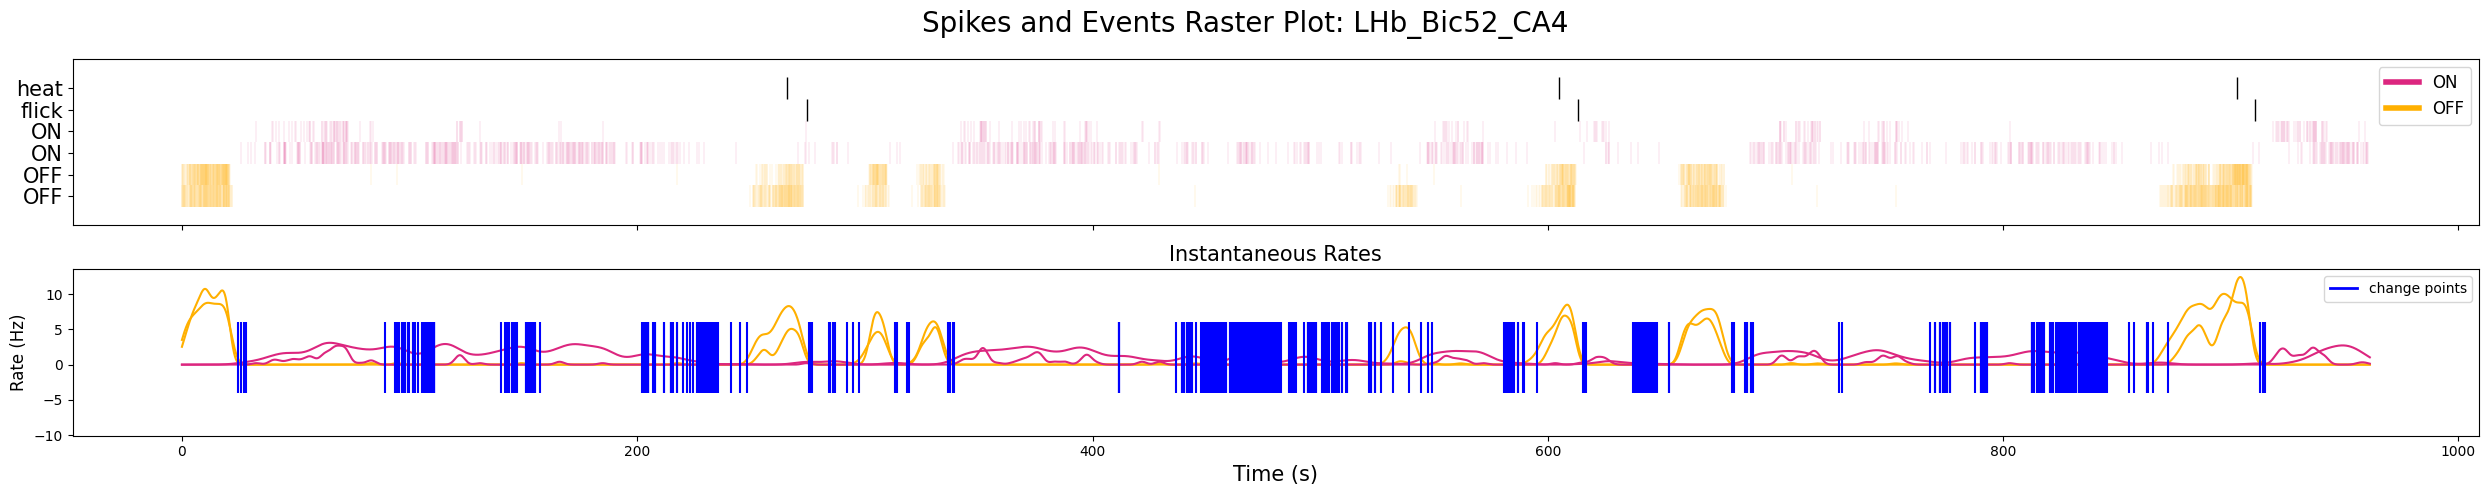

..\..\data\Further_ON_OFF_Pairs_Mary\spike_files\LHb_Mus03_CA3.smrx


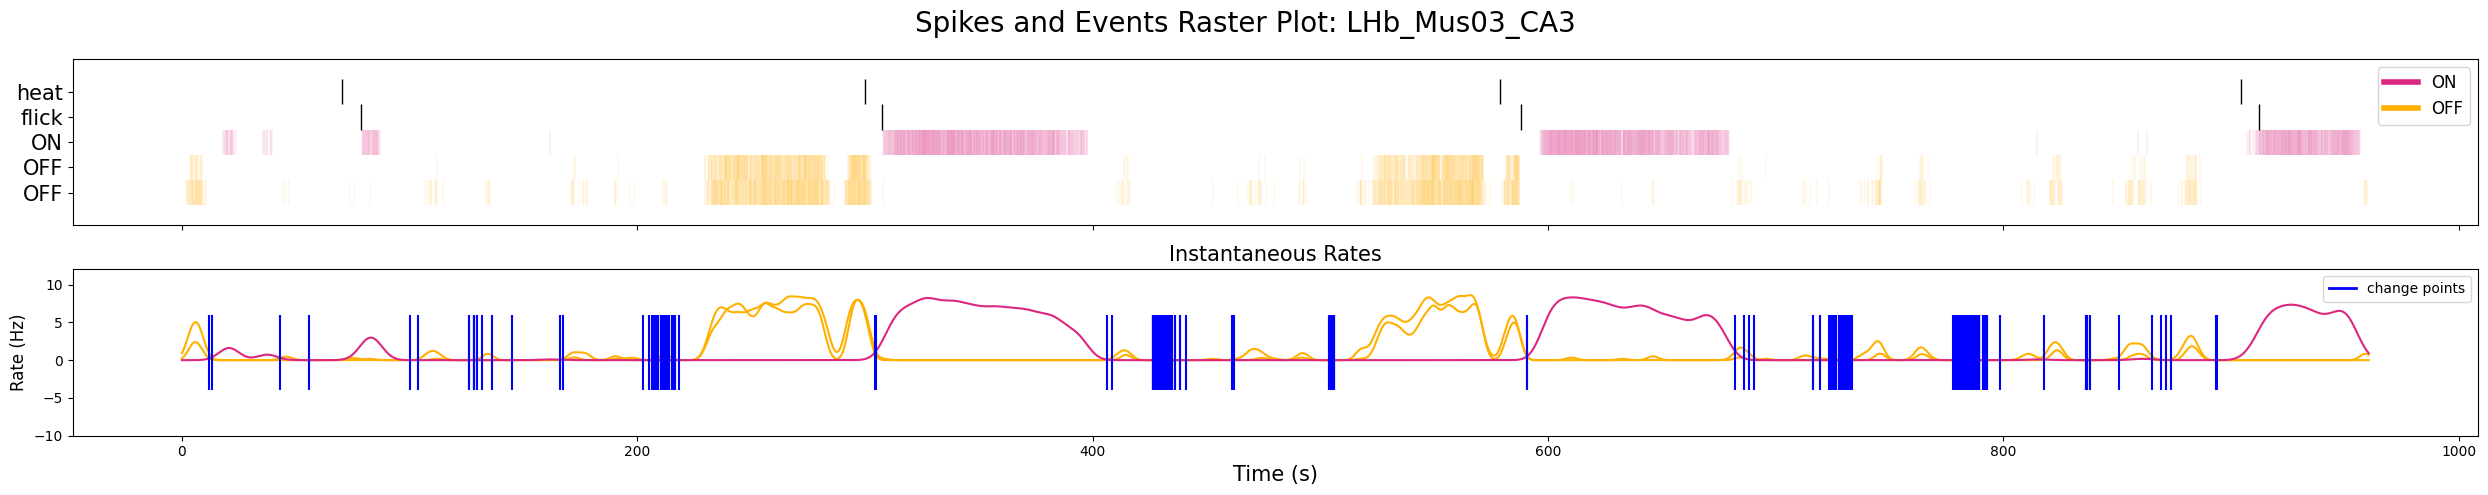

..\..\data\Further_ON_OFF_Pairs_Mary\spike_files\LHb_Mus06_CA2.smrx


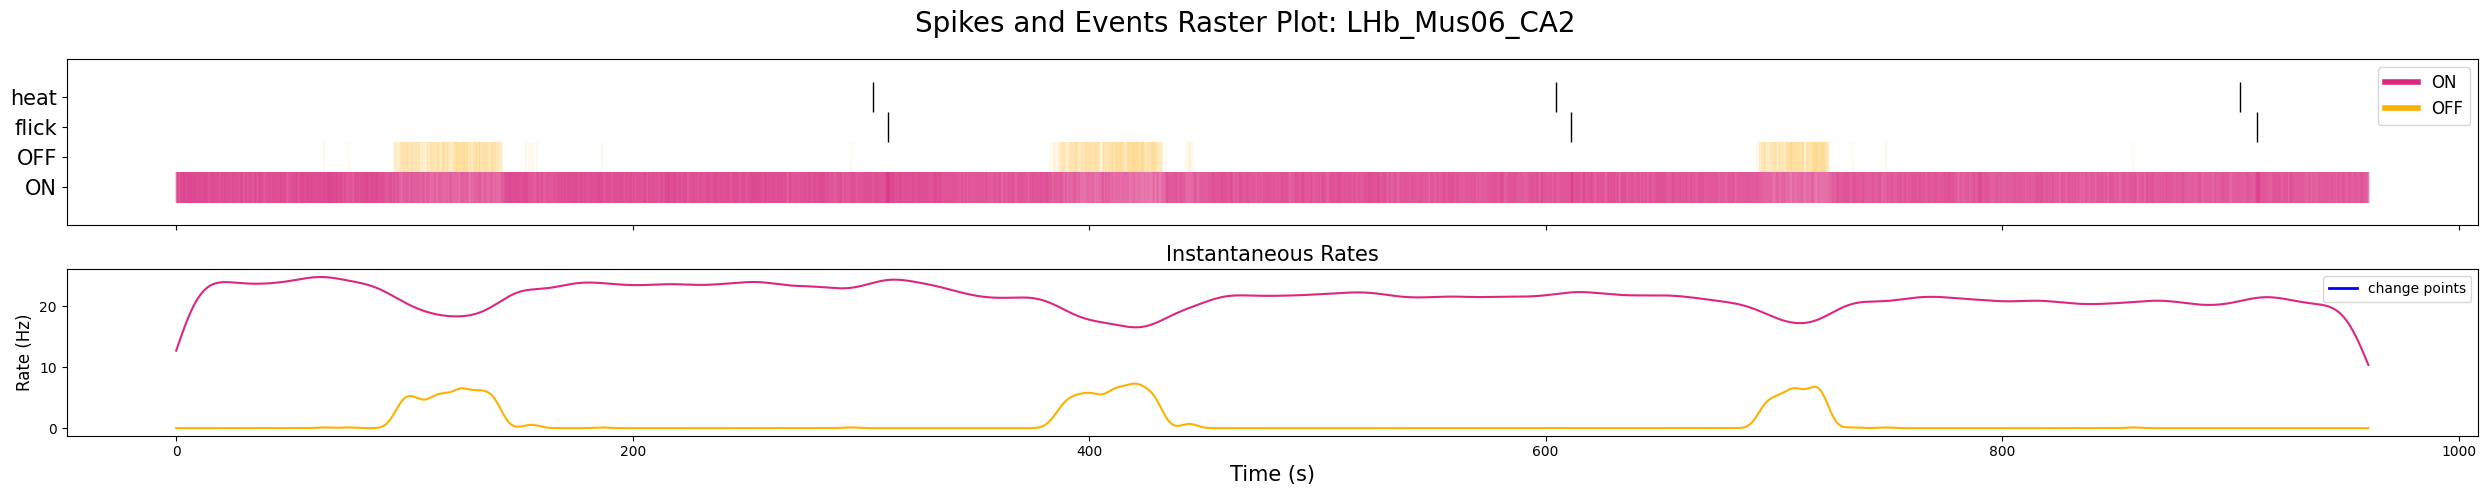

..\..\data\Further_ON_OFF_Pairs_Mary\spike_files\LHb_Mus07_CA2.smrx


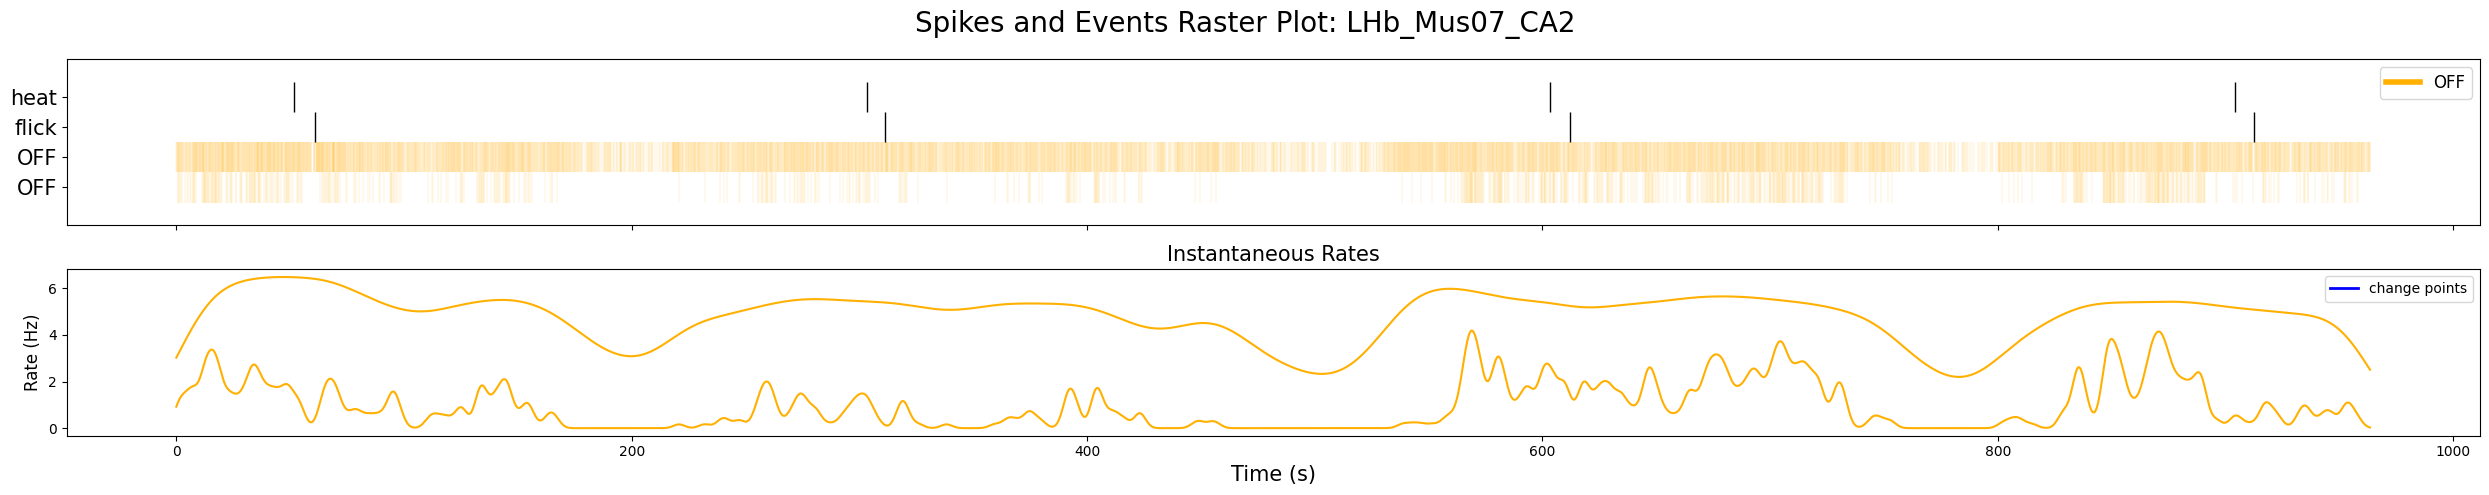

..\..\data\Further_ON_OFF_Pairs_Mary\spike_files\LHb_Mus09_CA2.smrx


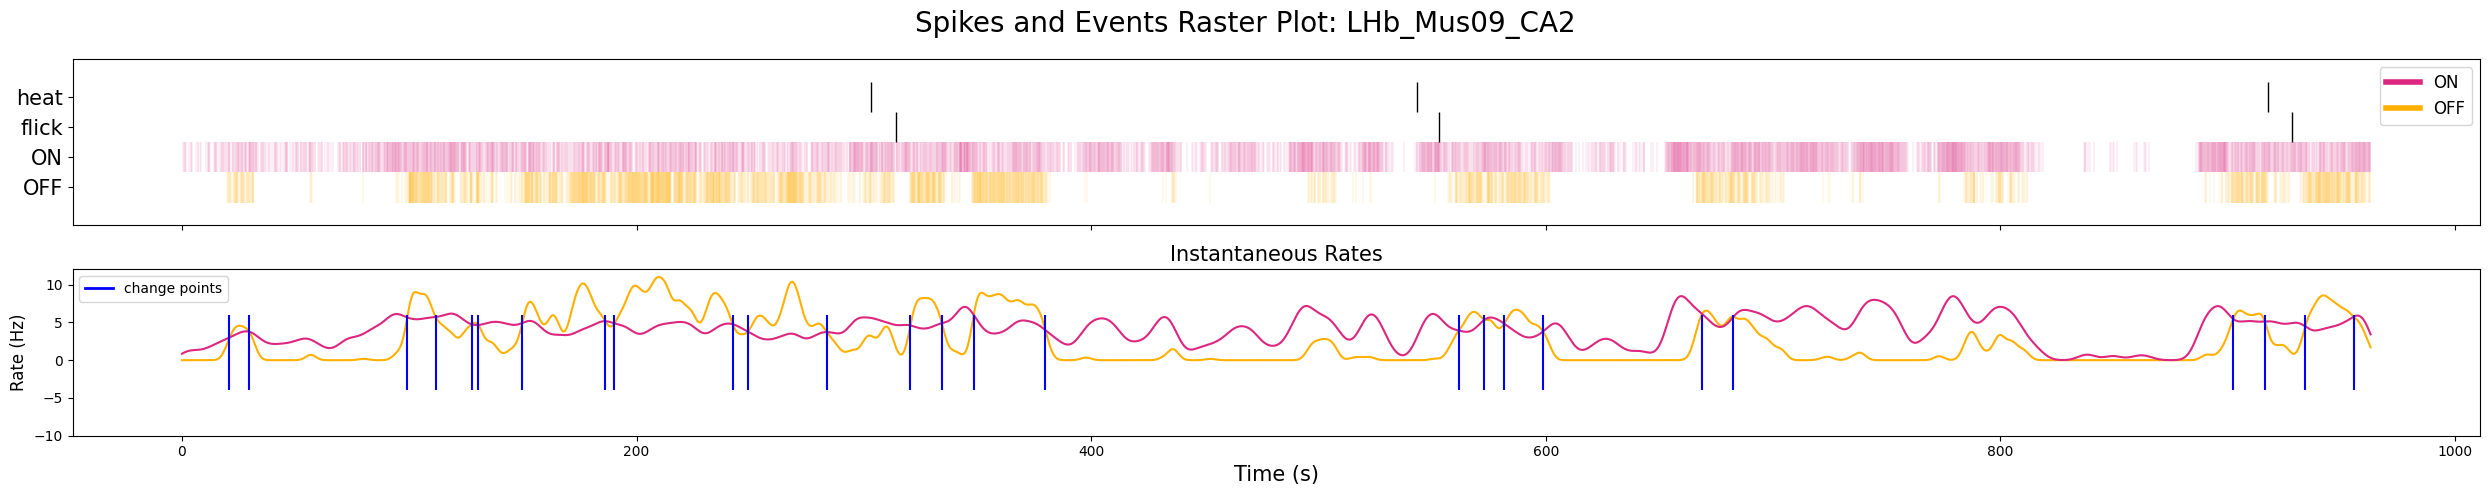

..\..\data\Further_ON_OFF_Pairs_Mary\spike_files\LHb_Mus13_CA2.smrx


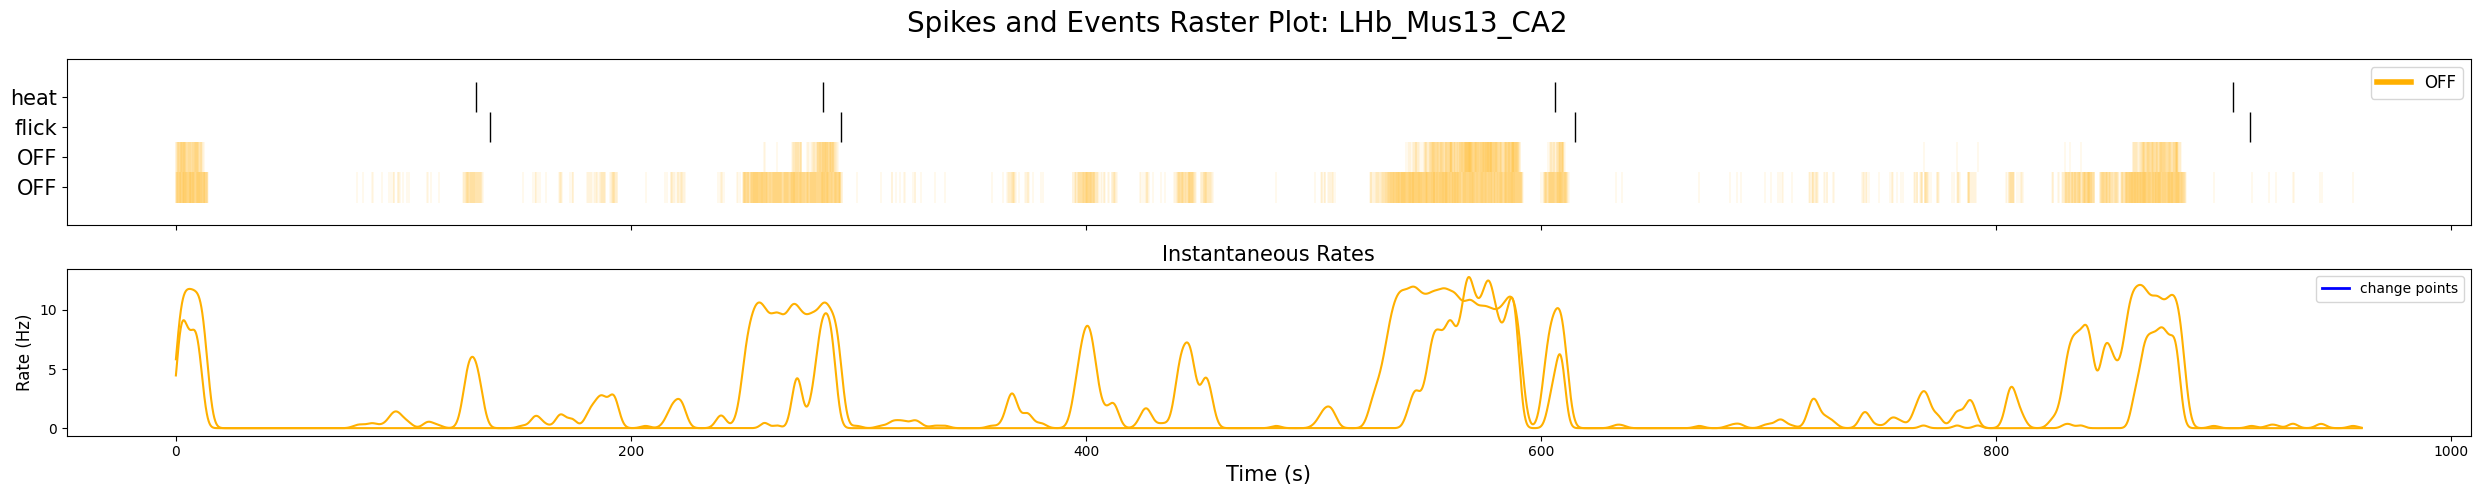

..\..\data\Further_ON_OFF_Pairs_Mary\spike_files\LHb_Mus14_CA2.smrx


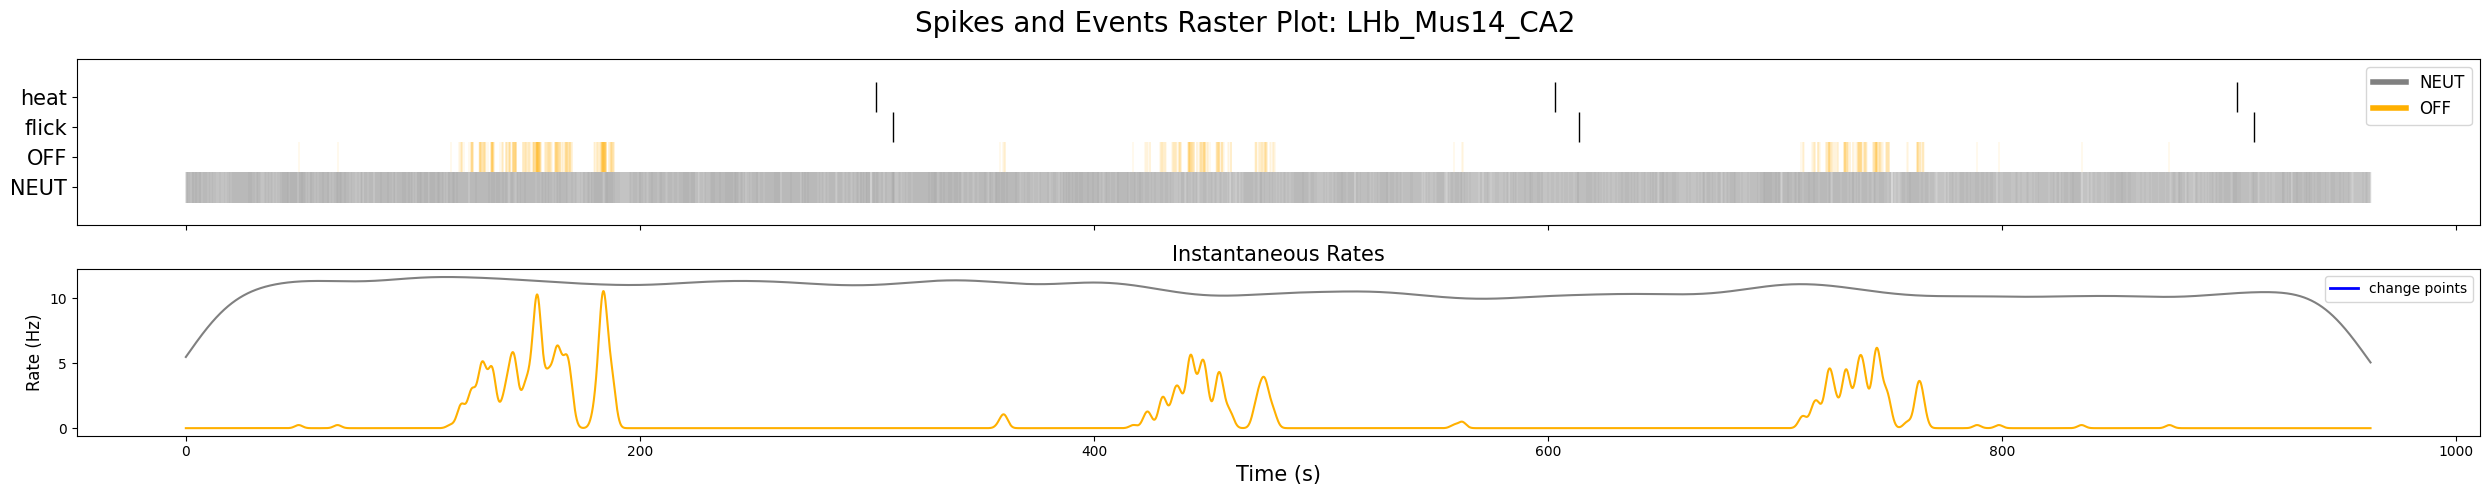

..\..\data\Further_ON_OFF_Pairs_Mary\spike_files\LHb_Mus15_CA2.smrx


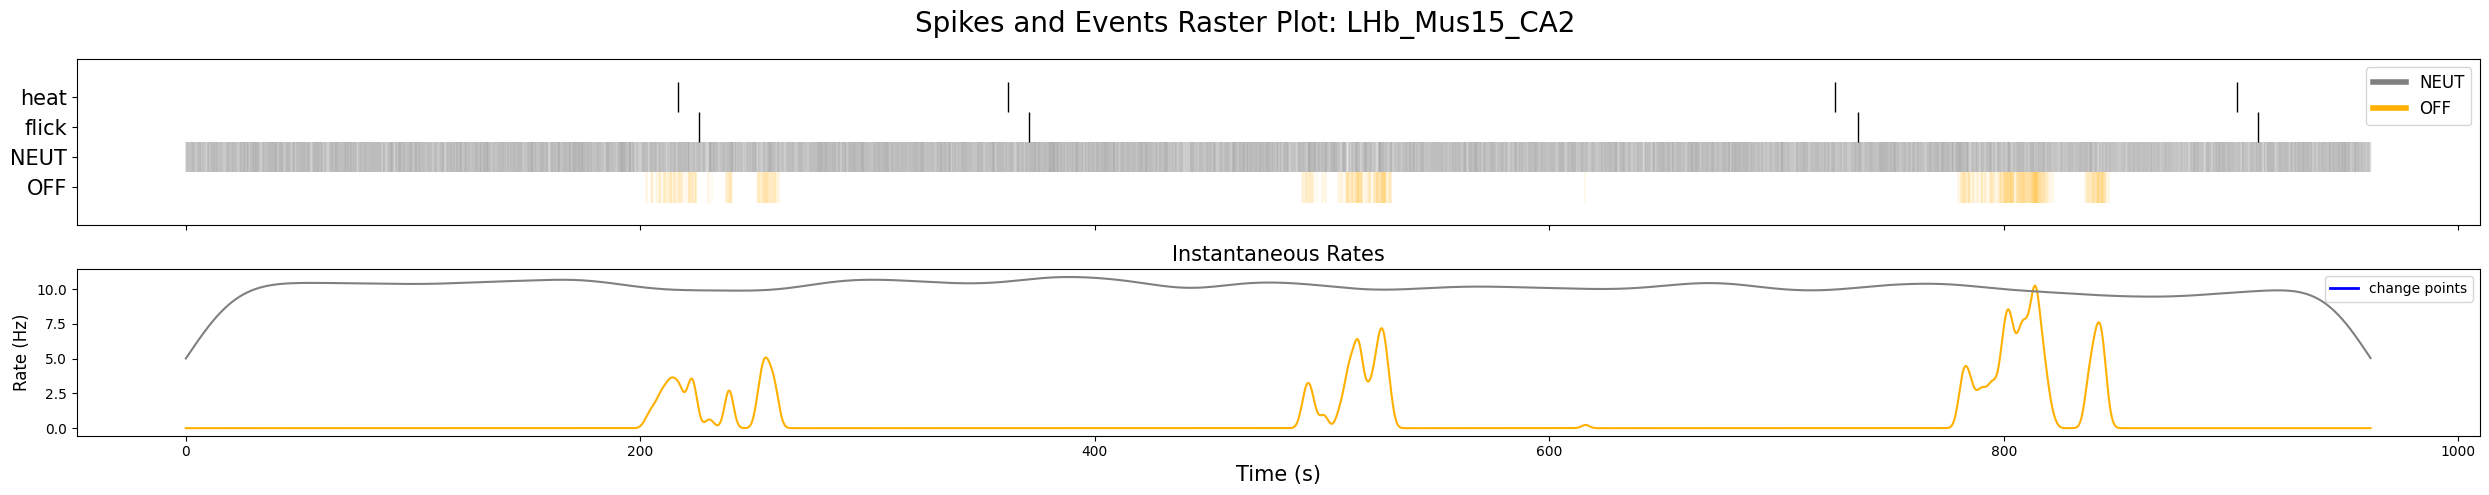

..\..\data\Further_ON_OFF_Pairs_Mary\spike_files\LHb_Mus16_CA2.smrx


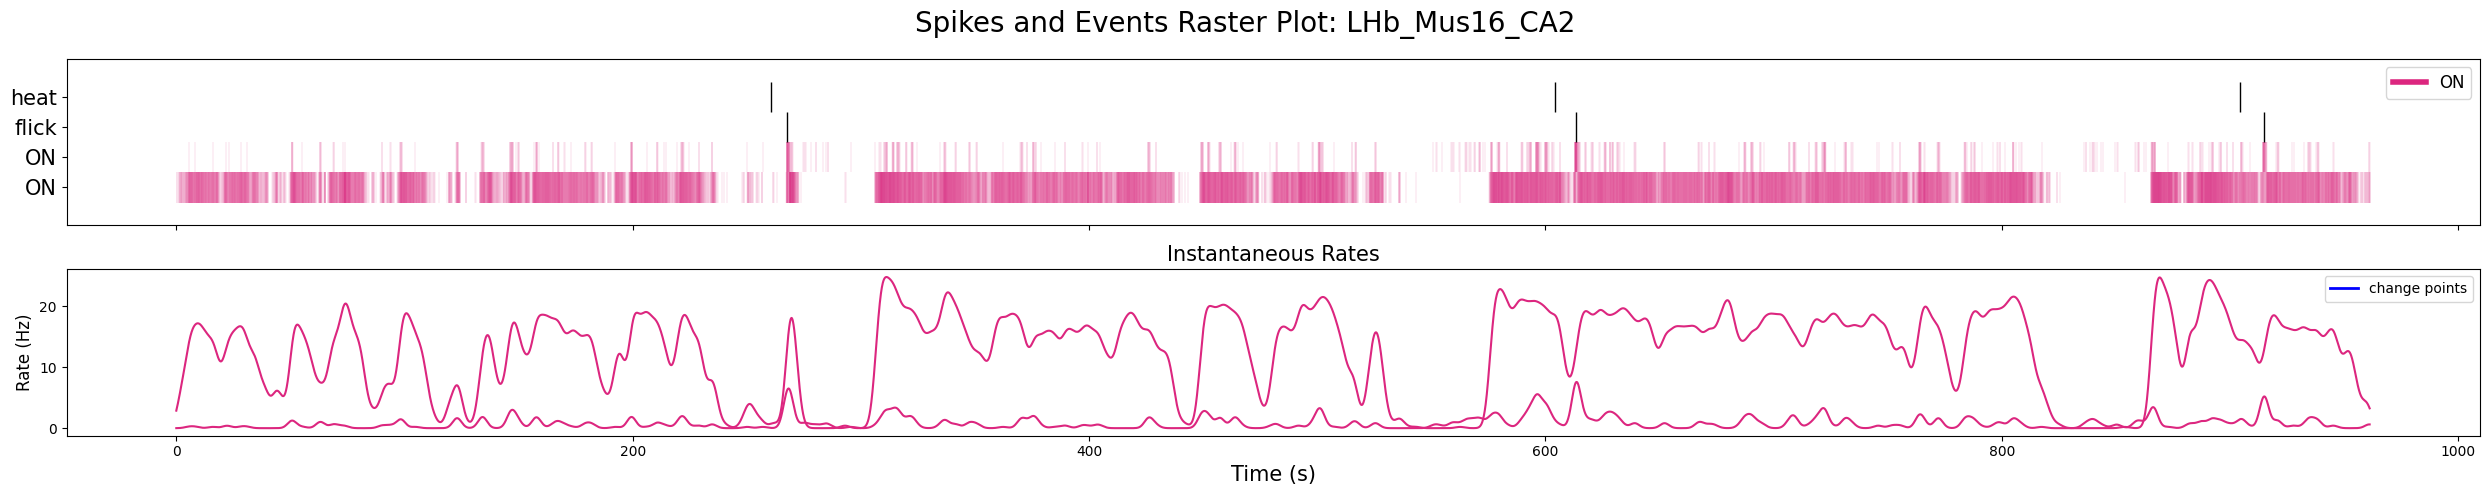

..\..\data\Further_ON_OFF_Pairs_Mary\spike_files\LHb_Mus22_CA2.smrx


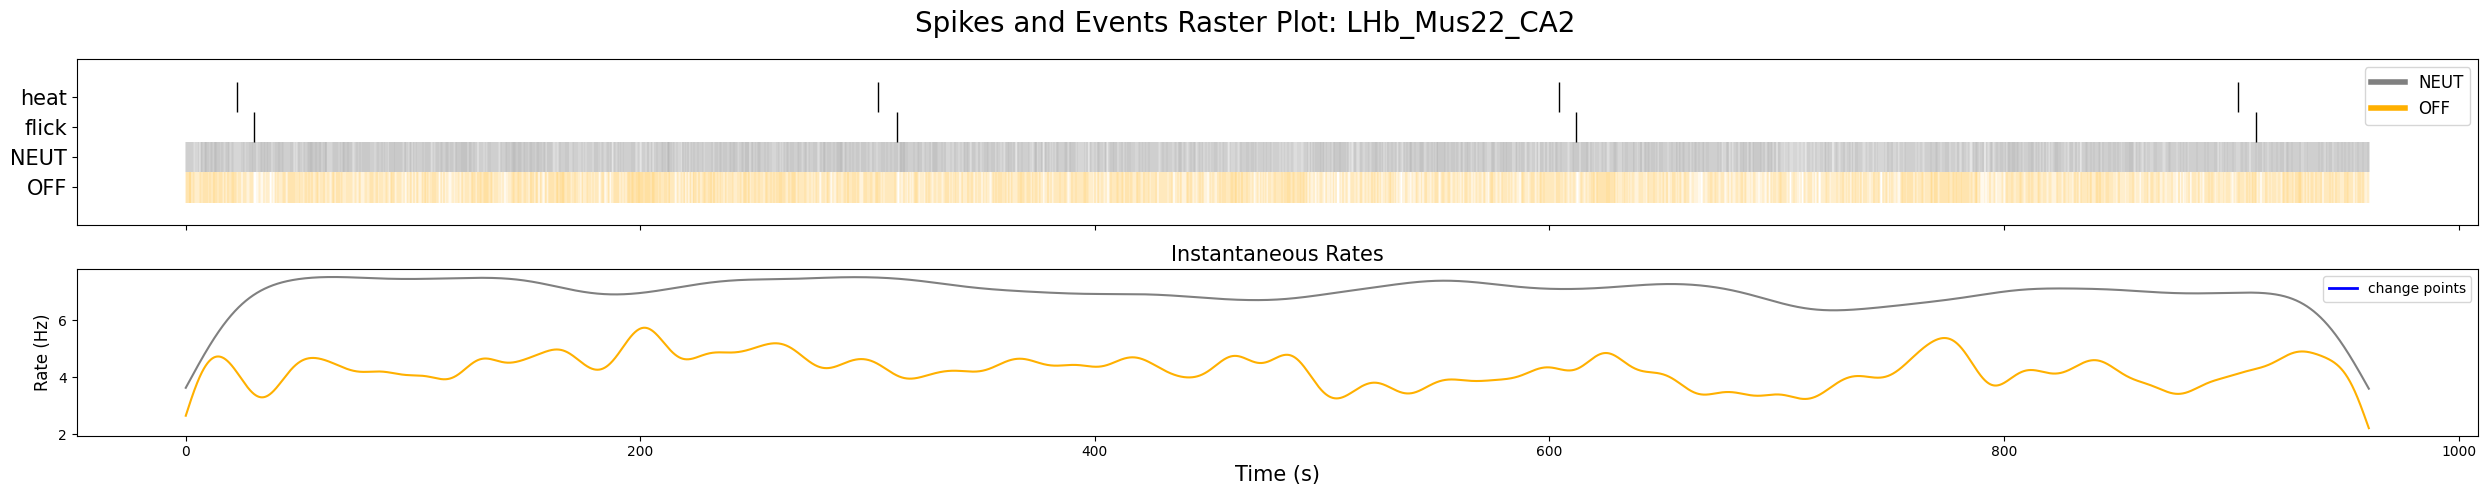

..\..\data\Further_ON_OFF_Pairs_Mary\spike_files\LHb_Mus23_CA2.smrx


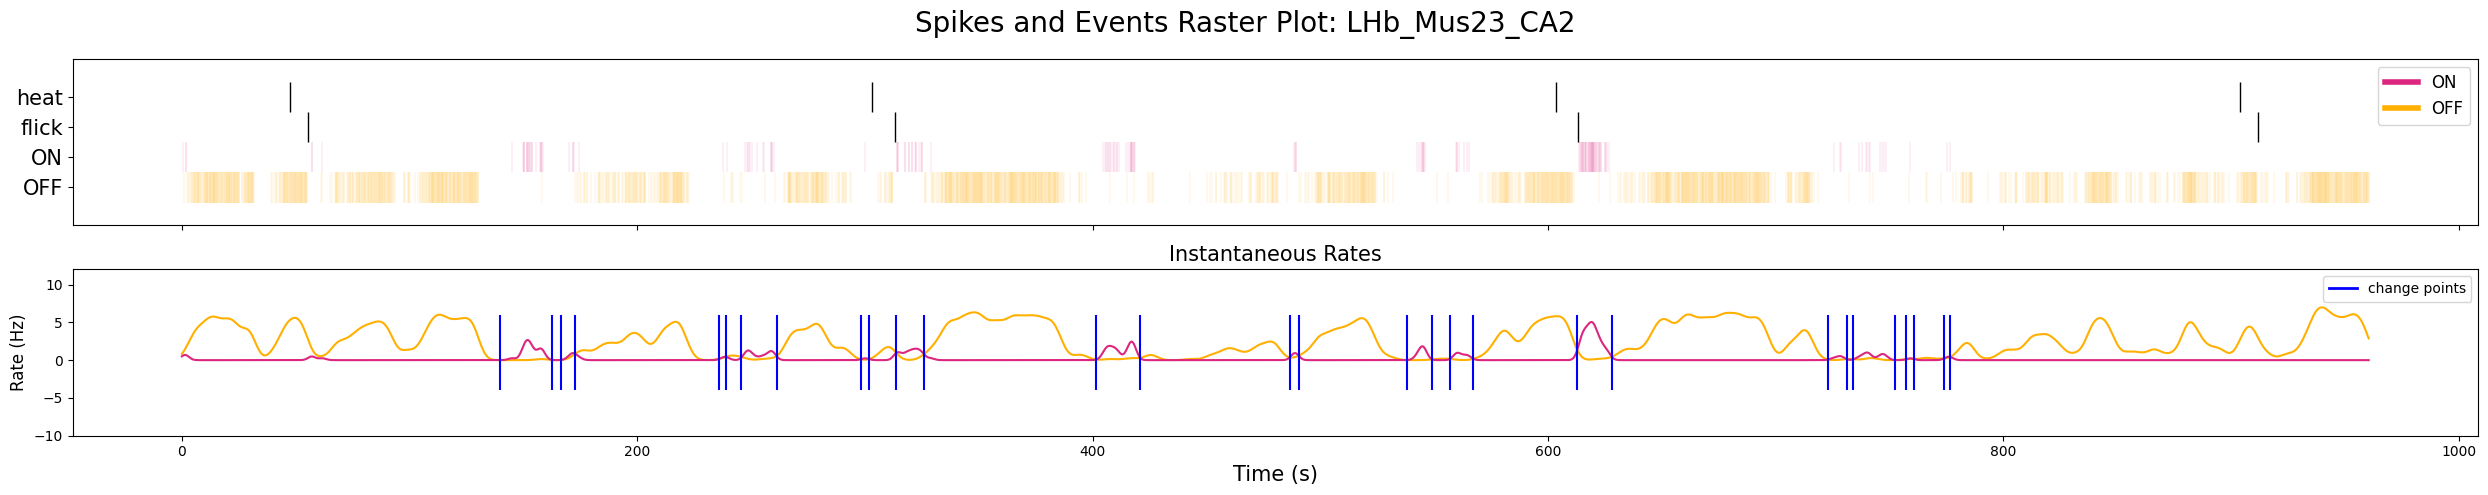

..\..\data\Further_ON_OFF_Pairs_Mary\spike_files\LHb_Mus25_CA2.smrx


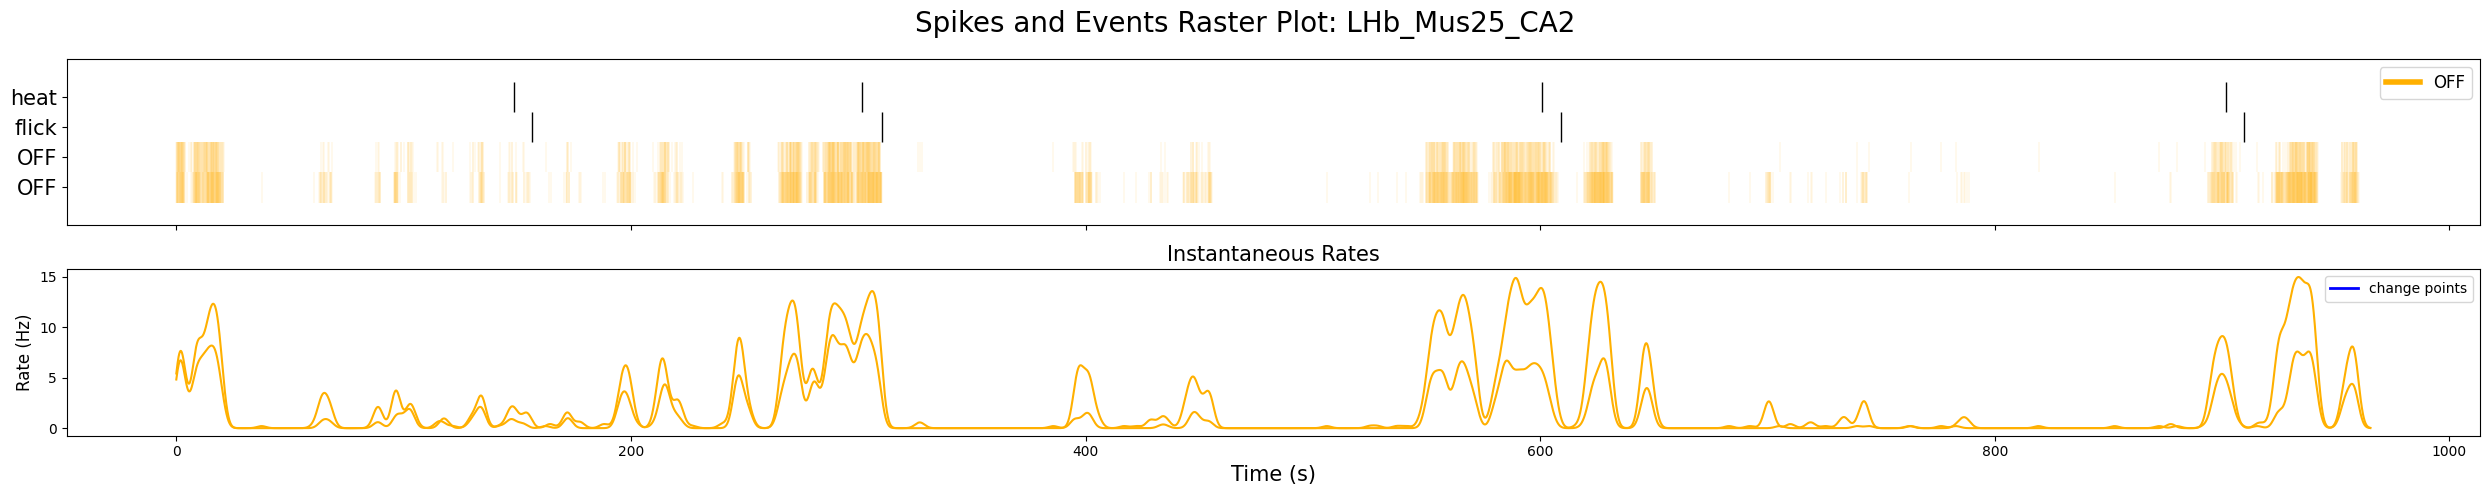

..\..\data\Further_ON_OFF_Pairs_Mary\spike_files\LHb_Mus28_CA2.smrx


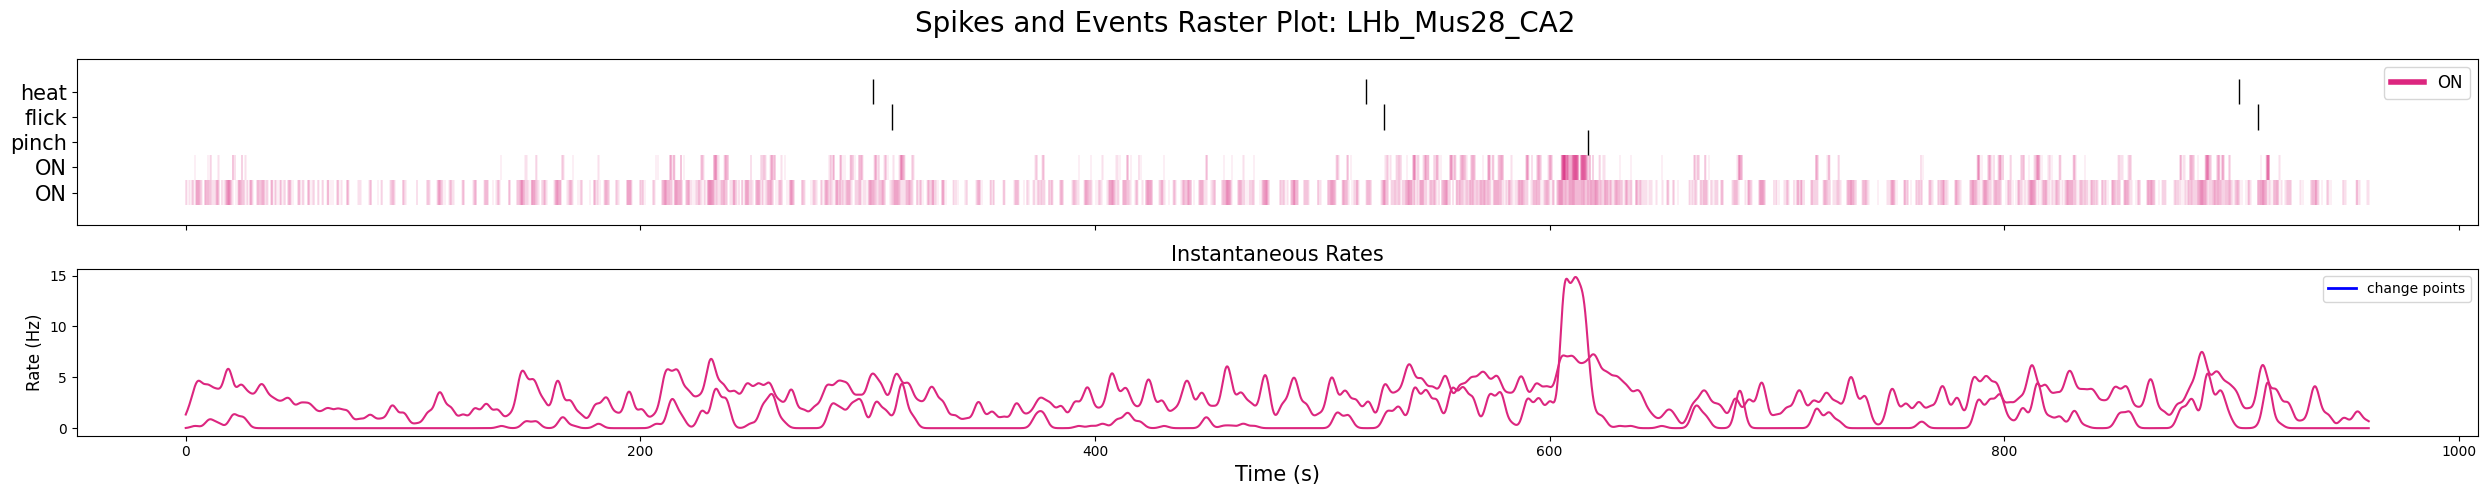

In [7]:
def remove_bicuculline_and_muscimol(dms,names_to_remove = ["bicuculline_infusion","muscimol_infusion"]):
    """
    Takes a set of data managers and goes through them,
    and cuts any blocks which have a drug infusion at the start time of the drug infusion.
    """
    for dm in dms:
        for i, block in enumerate(dm.blocks):
            segment:neo.Segment = block.segments[0]
            for event in segment.events:
                if event.name in names_to_remove:
                    block.segments[0] = segment.time_slice(0*s,event[0])

                    seg = block.segments[0]
                    seg.events = [ev for ev in seg.events if ev.name not in names_to_remove]

                    dm.plot_blocks(slice(i,i+1))
    
    return dms

dms = remove_bicuculline_and_muscimol(dms)

In [ ]:
def load_exp_subject_dataframe_excel(file_path: str) -> pd.DataFrame:
    """
    Load Excel file and return a DataFrame with only
    id, Weight, and Weight (kg) derived columns.
    """
    df = pd.read_excel(file_path)

    required_columns = ["id", "weight", "weight_kg","sex","session_type","animal_id","age_range","experimenter","session_id"]
    missing = set(required_columns) - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns in Excel file: {missing}")

    return df[required_columns]


In [ ]:
def get_exp_and_subject_excel_data_by_id(
    df: pd.DataFrame,
    query_id,
    columns=["id","weight_kg", "sex", "session_type", "animal_id", "age_range","experimenter","session_id"]
):
    """Return the required columns of the dataframe for a given id, as a list."""
    
    result = df.loc[df["id"] == query_id, columns]

    if result.empty:
        raise KeyError(f"No entry found for id: {query_id}")

    # Return the first (only) matching row as a list
    return result.iloc[0].to_dict()


In [10]:
session_descriptions = {
    "evoked": "Lightly anesthetized rat recordings with \
        approximately 5 minute spaced hindpaw heat stimulation.",
    "ongoing": "Lightly anesthetized rat recordings with cell-type \
        confirmatory stimulation at the start and end, and a period of unstimulated \
            activity in the middle.",
    "evoked/ongoing": "Lightly anesthetized rat recordings with \
        approximately 5 minute spaced hindpaw heat stimulation. No difference in experimental setup  to the evoked protocol, \
            but the (Neutral) Cell/s did not respond to stimulation, so these recordings were included in the GP analysis.",

}

experiment_descriptions = {
    "evoked": "Recordings of RVM response to noxious heat applied to the hindpaw to determine cell classification. No prolonged periods of unstimulated activity.",
    "ongoing": "Prolonged unstimulated RVM recordings in between tests of cell responses to noxious heat applied to the hindpaw for cell classification.",
    "evoked/ongoing": "Recordings of RVM recordings in Neutral cells, where the cell did not respond to noxious stimulation. \
        The full recordings of these cells, including over the trials were used to supplement the GP fitting, as the cells did not respond to noxious stimulation."
}

event_descriptions = {
    "heat": "Times of hindpaw heat ramp onset.",
    "paw_withdrawal": "Times of paw withdrawal, determined from an implanted EMG.",
    "pinch": "Markers indincating pinch stimulation. Each pinch lasted approximately 10 seconds. Each pinch marker has a label, giving the location (left hindpaw, right hindpaw, tail, ear) and whether the marker is an onset time, release time, or approximate onset and release ('approx').",
    "EKG": "Times of heart beats of the rat, automatically determined from EKG."
}

In [ ]:


assert(len(validate_excel("../../data/weights_and_ids.xlsx")) == 0)


df = load_exp_subject_dataframe_excel("../../data/weights_and_ids.xlsx")

display(df)

data_save_path = Path("./saved_nwb_data")
data_save_path.mkdir(exist_ok=True)

SESSION_START = datetime(2000, 1, 1) # Setting this to the same value of all files for now, as I can't easily get it from the smrx file, and it isn't used in our analyses.

rat_index = 0
for dm in dms:
    for block in dm.blocks:
        file_origin = Path(block.file_origin)

        # Get all the ages, weights, session_ids etc from the excel file
        exp_sub_data = get_exp_and_subject_excel_data_by_id(df,file_origin.stem)

        localised_time = block.rec_datetime.replace(tzinfo=ZoneInfo("America/Los_Angeles")) # Localise to pacific time
        segment: neo.Segment = block.segments[0]
        

        # Add labels for events
        for event in block.segments[0].events:
            event: neo.Event
            if event.name == "heat":
                event.labels = ["heat_onset"] * len(event)
            elif event.name == "flick":
                event.labels = ["paw_withdrawal"] * len(event)
                event.name = "paw_withdrawal"


        spike_names = [sp.name for sp in block.segments[0].spiketrains]

        # keywords = list(map(str, ["RVM", "Rat", "Pain","Nociception", f"{exp_sub_data['session_type']}"] + spike_names))
        # print("keywords:", keywords)
        # Couldn't get Keywords to work.

        # Create an NWB file
        nwbfile: NWBFile = NWBFile(
            session_description=str(session_descriptions[exp_sub_data['session_type']]),
            experiment_description=str(experiment_descriptions[exp_sub_data['session_type']]),
            identifier=str(exp_sub_data['id']),
            session_start_time=localised_time,
            lab="Heinricher Lab",
            institution="Oregon Health and Science University",
            related_publications="https://doi.org/10.64898/2025.12.15.693905",
            session_id=str(int(exp_sub_data['session_id'])),
            experimenter=exp_sub_data['experimenter'],
            protocol=exp_sub_data['session_type']
        )

        # Add a subject
        nwbfile.subject = Subject(
            subject_id=f"rat_{int(exp_sub_data['animal_id'])}",
            description=f"Lightly Anesthetized Headfixed Rat",
            species="Rattus norvegicus",
            strain="Sprague-Dawley",
            weight=exp_sub_data['weight_kg'],
            sex=exp_sub_data['sex'],
            age=exp_sub_data['age_range'],
        )

        # Store the experimenter derived cell classes
        nwbfile.add_unit_column(
            name="_name",
            description="The experimenter defined name of the spiketrain, based on change in firing rate before the withdrawal."
        )

        # Before adding units
        nwbfile.add_unit_column(
            name="segment",
            description="Segment name for Neo"
        )
        nwbfile.add_unit_column(
            name="block",
            description="Block name for Neo"
        )

        # Paw withdrawals are processed events, even though the raw data isn't present.
        # However, if I use processing then neo can't import the nwb files, so the rest of the pipeline breaks.
        # So, we are treating them as acquisitions for now.
        # behavior_module = nwbfile.create_processing_module(
        #     name="behavior", description="Processed Paw Withdrawal Times"
        # )

        for segment in block.segments:

            # Store the heat onsets and the paw withdrawals
            print([event.name for event in segment.events])
            print([signal.name for signal in segment.analogsignals])
            for event in segment.events:
                

                times = np.array(event.times.rescale("seconds").magnitude)
                labels = np.array(["unknown"] * len(times)) 
                if event.name == "heat":
                    labels = np.array(["heat_onset"] * len(times)) 
                elif event.name == "paw_withdrawal":
                    labels = np.array(["paw_withdrawal"] * len(times))
                elif event.name == "pinch":
                    labels = event.labels
                print(event.labels)
                hierarchy = {"block": "block0", "segment": "seg0"}
                description = event_descriptions[event.name]

                ann_series = AnnotationSeries(
                    name=event.name,
                    data=labels,
                    timestamps=times,
                    description=description,
                    comments=json.dumps(hierarchy)
                )

                if len(event) != 0:
                    if event.name in ["EKG"]:
                        print(f"added {event.name}")
                        nwbfile.add_acquisition(ann_series)
                    elif event.name in ["heat","pinch"]:
                        nwbfile.add_stimulus(ann_series)
                    elif event.name == "paw_withdrawal":
                        # behavior_module.add(ann_series)
                        nwbfile.add_acquisition(ann_series)
                else:
                    print(f"left out empty event {event.name}")


            # Spike trains to Units table
            for i, st in enumerate(segment.spiketrains):
                st_times = np.array(st.rescale("seconds").magnitude)
                nwbfile.add_unit(
                    id=i,
                    spike_times=st_times,
                    obs_intervals=[[float(st.t_start.rescale("seconds").magnitude),float(st.t_stop.rescale("seconds").magnitude)]],
                    electrode_group=None,
                    electrodes=None,
                    **{"_name": st.name,
                       "segment": "seg0",
                       "block": "block0"}  # ensures 'name' column gets spiketrain name
                )

            # Analog signals to ElectricalSeries
            # for ana in segment.analogsignals:
            #     data = np.array(ana.magnitude)  # units already in Neo
            #     rate = float(ana.sampling_rate.rescale("Hz").magnitude)
            #     name = ana.name or "analog_signal"
            #     e_series = ElectricalSeries(
            #         name=name,
            #         data=data,
            #         electrodes=None,  # optional: add ElectrodeTable if you have info
            #         starting_time=float(ana.t_start.rescale("seconds").magnitude),
            #         rate=rate,
            #         description=ana.description or "",
            #     )
            #     nwbfile.add_acquisition(e_series)  # top-level acquisition

        #save NWB
        save_path = (data_save_path / file_origin.stem).with_suffix(".nwb")
        with NWBHDF5IO(save_path, "w") as io:
            io.write(nwbfile)

        rat_index +=1

        print(f"Saved NWB file: {save_path}")


,id,weight,weight_kg,sex,session_type,animal_id,age_range,experimenter,session_id
0,LHb_Mus03_CA3,273.0,0.273,M,evoked,1.0,P08W/P12W,"Martenson, Melissa",1.0
1,LHb_Mus06_CA2,256.0,0.256,M,evoked,2.0,P08W/P12W,"Martenson, Melissa",1.0
2,LHb_Mus07_CA2,249.0,0.249,M,evoked,3.0,P08W/P12W,"Martenson, Melissa",1.0
3,LHb_Mus09_CA2,309.0,0.309,M,evoked,4.0,P08W/P12W,"Martenson, Melissa",1.0
4,LHb_Mus13_CA2,254.0,0.254,M,evoked,5.0,P08W/P12W,"Martenson, Melissa",1.0
...,...,...,...,...,...,...,...,...,...
106,Neutral ongoing 8-7-24 #1@2797_pared,191.0,0.191,F,ongoing,80.0,P08W/P12W,"Shi, Zhigang",1.0
107,Neutral ongoing 8-7-24 #2@2984_pared,191.0,0.191,F,ongoing,80.0,P08W/P12W,"Shi, Zhigang",2.0
108,Neutral ongoing 8-8-24@3195_pared,199.0,0.199,F,ongoing,81.0,P08W/P12W,"Shi, Zhigang",1.0
109,Neutral ongoing 9-4-24 @2670_pared,324.0,0.324,F,ongoing,82.0,P08W/P12W,"Shi, Zhigang",1.0


['heat', 'paw_withdrawal']
[]
['heat_onset' 'heat_onset' 'heat_onset']
['paw_withdrawal' 'paw_withdrawal' 'paw_withdrawal']
Saved NWB file: saved_nwb_data\DMHLido20_BL_cut.nwb
['heat', 'paw_withdrawal']
[]
['heat_onset' 'heat_onset' 'heat_onset' 'heat_onset']
['paw_withdrawal' 'paw_withdrawal' 'paw_withdrawal' 'paw_withdrawal']
Saved NWB file: saved_nwb_data\DP_DTT_Bic02_BL_cut.nwb
['heat', 'paw_withdrawal']
[]
['heat_onset' 'heat_onset' 'heat_onset']
['paw_withdrawal' 'paw_withdrawal' 'paw_withdrawal']
Saved NWB file: saved_nwb_data\HDB_Bic06_BL_cut.nwb
['heat', 'paw_withdrawal']
[]
['heat_onset' 'heat_onset' 'heat_onset']
['paw_withdrawal' 'paw_withdrawal' 'paw_withdrawal']
Saved NWB file: saved_nwb_data\HDB_Bic11_BL_cut.nwb
['heat', 'paw_withdrawal']
[]
['heat_onset' 'heat_onset' 'heat_onset']
['paw_withdrawal' 'paw_withdrawal' 'paw_withdrawal']
Saved NWB file: saved_nwb_data\HDB_Mus20_BL_cut.nwb
['heat', 'paw_withdrawal']
[]
['heat_onset' 'heat_onset' 'heat_onset' 'heat_onset']
['p

In [12]:
def test_open_file(file_name,data_save_path=Path("saved_nwb_data")):

    # open_path = data_save_path / "DMHLido20_BL_cut.nwb"
    open_path = data_save_path /file_name

    # Using context manager automatically closes the file
    with NWBHDF5IO(path=open_path, mode='r') as io:
        nwb = io.read()  # nwb is now a pynwb.NWBFile object
        
        display(nwb)

test_open_file( "DP_DTT_Bic02_BL_cut.nwb")
test_open_file( "Neutral ongoing 8-7-24 #2@2984_pared.nwb")
test_open_file( "HDB_Bic56_cut_truncated.nwb")
test_open_file( "LHb_Mus22_CA2.nwb")
# test_open_file("sub-rat-12_ses-1.nwb",data_save_path=Path("../../data/dandiset/sub-rat-12/"))

Data type,object
Shape,"(4,)"
Array size,32.00 bytes
Chunk shape,None
Compression,None
Compression opts,None
Uncompressed size (bytes),32
Compressed size (bytes),64
Compression ratio,0.5
Data type,float64
Shape,"(4,)"


Data type,object
Shape,"(20007,)"
Array size,156.30 KiB
Chunk shape,None
Compression,None
Compression opts,None
Uncompressed size (bytes),160056
Compressed size (bytes),320112
Compression ratio,0.5
Data type,float64
Shape,"(20007,)"


Data type,object
Shape,"(5974,)"
Array size,46.67 KiB
Chunk shape,None
Compression,None
Compression opts,None
Uncompressed size (bytes),47792
Compressed size (bytes),95584
Compression ratio,0.5
Data type,float64
Shape,"(5974,)"


Data type,object
Shape,"(6487,)"
Array size,50.68 KiB
Chunk shape,None
Compression,None
Compression opts,None
Uncompressed size (bytes),51896
Compressed size (bytes),103792
Compression ratio,0.5
Data type,float64
Shape,"(6487,)"


In [23]:
from rvm_analysis.utils import import_NWB_data


def import_all_saved_data():
    dm = import_NWB_data(Path("./saved_nwb_data/"))

    for block in dm.blocks:
        keyboard = block.segments[0].filter(name="pinch")
        if len(keyboard) !=0:
            print(keyboard[0].labels)

import_all_saved_data()

['l_hpaw_onset' 'l_hpaw_release' 'r_hpaw_onset' ' r_hpaw_release'
 'r_hpaw_onset' ' r_hpaw_release' ' ear_onset' ' ear_release']
['tail_onset' 'tail_release' 'ignore' 'tail_release']
['r_hpaw_onset' 'r_hpaw_release' 'tail_onset' 'tail_release']
['tail_onset' 'tail_release']
['tail_onset' 'tail_release_post_pinch_slip' 'tail_onset' 'tail_release'
 'ignore' 'ignore' 'ignore']
['l_hpaw_onset']
['l_hpaw_onset_approx' 'l_hpaw_release_approx']
['l_hpaw_onset_approx' 'l_hpaw_release_approx']
['l_hpaw_onset_approx' 'l_hpaw_release_approx']
['l_hpaw_onset' ' l_hpaw_release']
['l_hpaw_onset' ' l_hpaw_release']
['l_hpaw_onset' ' l_hpaw_release' ' ignore' 'ignore' 'ignore' 'ignore']
['l_hpaw_onset' ' l_hpaw_release']
['l_hpaw_onset' ' l_hpaw_release']
['l_hpaw_onset' ' l_hpaw_release']
['l_hpaw_onset' ' l_hpaw_release']
['l_hpaw_onset' ' l_hpaw_release']
['l_hpaw_onset' ' l_hpaw_release']
['l_hpaw_onset' ' l_hpaw_release']
['l_hpaw_onset' ' l_hpaw_release' 'l_hpaw_onset' ' l_hpaw_release']
['l_hpa